# Import

In [31]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  

import re

# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

### Loading datasets
The followingsnippet loads datasets `data/train.csv` and `data/test.csv` into two Pandas DataFrame.

In [32]:
data_train = pd.read_csv("data/train.csv")  # Loads the training dataset from a CSV file into a Pandas DataFrame.
data_test = pd.read_csv("data/test.csv")    # Loads the testing dataset from a CSV file into a Pandas DataFrame.

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


### Shape and info of data_train
The code displays the shape of the `data_train` DataFrame, including the total number of rows (records) and columns (features). It then provides metadata about the `data_train` DataFrame using the `info()` method, which includes data types for each column, the count of non-null values, memory usage, and other structural details of the dataset.

In [33]:
print("-------------------------- SHAPE -----------------------")
print(data_train.shape, f"-> {data_train.shape[0]} records and {data_train.shape[1]} features")
print("-------------------------- INFO ------------------------")
print(data_train.info())

-------------------------- SHAPE -----------------------
(16431, 23) -> 16431 records and 23 features
-------------------------- INFO ------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16431 entries, 0 to 16430
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   originalTitle                16431 non-null  object 
 1   rating                       16431 non-null  object 
 2   startYear                    16431 non-null  int64  
 3   endYear                      16431 non-null  object 
 4   runtimeMinutes               16431 non-null  object 
 5   awardWins                    13813 non-null  float64
 6   numVotes                     16431 non-null  int64  
 7   worstRating                  16431 non-null  int64  
 8   bestRating                   16431 non-null  int64  
 9   totalImages                  16431 non-null  int64  
 10  totalVideos                  16

### Statistical overview 

The output of `data_train.describe(include='all').T` provides a comprehensive statistical summary for all columns in the dataset, transposed for better readability.
This summary provides key insights into the data distribution, central tendencies, and frequency-based statistics for both numerical and categorical data.

#### Output

- **Numerical Columns**:
  - **count**: The total number of non-null values in each column.
  - **mean**: The average value of the column.
  - **std**: The standard deviation, representing the spread of the data.
  - **min**: The smallest value in the column.
  - **25%**: The first quartile (25th percentile), representing the value below which 25% of the data falls.
  - **50%**: The median (50th percentile), representing the middle value of the data.
  - **75%**: The third quartile (75th percentile), representing the value below which 75% of the data falls.
  - **max**: The largest value in the column.

- **Categorical Columns**:
  - **count**: The total number of non-null values in each column.
  - **unique**: The number of unique values in the column.
  - **top**: The most frequent value (mode) in the column.
  - **freq**: The frequency of the most frequent value (count of occurrences).

- **Other Notes**:
  - Columns with mixed or object types may not include numerical statistics like mean or std.
  - For categorical data, `min`, `25%`, `50%`, `75%`, and `max` are not displayed.
  - Missing values are excluded from the calculations, so the `count` value might differ from the total number of rows.

In [34]:
data_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
originalTitle,16431,16054,Episode #1.1,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,16431,10,"(7, 8]",4822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
startYear,16431.0,NaN,NaN,NaN,1991.867081,26.12069,1878.0,1978.0,1997.0,2013.0,2024.0
endYear,16431,75,\N,15617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtimeMinutes,16431,244,\N,4852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
awardWins,13813.0,NaN,NaN,NaN,0.491855,2.974264,0.0,0.0,0.0,0.0,145.0
numVotes,16431.0,NaN,NaN,NaN,1492.153551,20137.708096,5.0,15.0,36.0,148.5,966565.0
worstRating,16431.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
bestRating,16431.0,NaN,NaN,NaN,10.0,0.0,10.0,10.0,10.0,10.0,10.0
totalImages,16431.0,NaN,NaN,NaN,11.477025,74.254261,0.0,1.0,1.0,6.0,3504.0


# Data understanding and preparation

## Columns description and types

| **Feature**                   | **Description**                                                                                 | **Data Type**  | **Nullability** |
|-------------------------------|-------------------------------------------------------------------------------------------------|----------------|-----------------|
| **originalTitle**             | Original title, in the original language.                                                      | Nominal        | Non-Null        |
| **runtimeMinutes**            | Primary runtime of the title, in minutes.                                                     | Ratio          | Non-Null        |
| **isAdult**                   | Whether or not the title is for adults (0: non-adult; 1: adult).                              | Binary         | -               |
| **startYear**                 | Release year of a title; for TV Series, the series start year.                                | Ordinal        | -               |
| **endYear**                   | TV Series end year.                                                                           | Numeric        | -               |
| **numVotes**                  | Number of votes the title has received.                                                       | Numeric        | -               |
| **numRegions**                | Number of regions for this version of the title.                                              | Nominal        | -               |
| **worstRating**               | Worst title rating.                                                                           | Ordinal        | -               |
| **bestRating**                | Best title rating.                                                                            | Ordinal        | -               |
| **canHaveEpisodes**           | Whether or not the title can have episodes.                                                   | Binary         | -               |
| **isRatable**                 | Whether or not the title can be rated by users.                                               | Binary         | -               |
| **totalImages**               | Total number of images for the title on the IMDb page.                                        | Numeric        | -               |
| **totalVideos**               | Total number of videos for the title on the IMDb page.                                        | Numeric        | -               |
| **totalCredits**              | Total number of credits for the title.                                                        | Numeric        | -               |
| **criticReviewsTotal**        | Total number of critic reviews.                                                               | Numeric        | -               |
| **awardWins**                 | Number of awards the title won.                                                               | Numeric        | -               |
| **awardNominationsExcludeWins** | Number of award nominations excluding wins.                                                   | Numeric        | -               |
| **titleType**                 | Type/format of the title (e.g., movie, short, tvseries, tvepisode, video, etc.).              | Categorical    | -               |
| **rating**                    | IMDb title rating class.                                                                      | Numeric        | -               |
| **ratingCount**               | Total number of user ratings submitted for the title.                                         | Ratio          | -               |
| **countryOfOrigin**           | Country where the title was primarily produced.                                               | Categorical    | -               |
| **genres**                    | Genre(s) associated with the title (e.g., drama, comedy, action).                            | Categorical    | -               |
| **userReviewsTotal**          | Total number of user reviews.                                                                 | Ratio          | -               |

### Original cathegorization
In order to group and display column names by data type for quick inspection and further processing, the following code snippet categorizes the columns of the `data_train` DataFrame by their data types and prints the column names for each category:

1. **Subset Creation**: `select_dtypes()` to create subsets of columns based on their data types (`int`, `float`, `bool`, and `object`).
2. **Organizing Subsets**: stores these subsets in a dictionary (`subsets`) where the keys are data type names, and values are the corresponding column subsets.
3. **Printing Column Names**: iterates through the subsets and prints the data type name and a list of column names belonging to that type.

In [35]:
# Subset of columns based on dtype
int_subset = data_train.select_dtypes(include=['int'])
float_subset = data_train.select_dtypes(include=['float'])
bool_subset = data_train.select_dtypes(include=['bool'])
object_subset = data_train.select_dtypes(include=['object'])

subsets = {"int" : int_subset, "float": float_subset, "bool": bool_subset, "object" : object_subset}

for t, subset in subsets.items():
    print("\n")
    print(f"Type {t} features:")
    print(subset.columns.tolist())



Type int features:
['startYear', 'numVotes', 'worstRating', 'bestRating', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'isAdult', 'numRegions', 'userReviewsTotal', 'ratingCount']


Type float features:
['awardWins']


Type bool features:
['canHaveEpisodes', 'isRatable']


Type object features:
['originalTitle', 'rating', 'endYear', 'runtimeMinutes', 'titleType', 'countryOfOrigin', 'genres']


#### Type analisys

| **Feature**                     | **Type**   | **Cast/Re-elaboration Needed** |
|----------------------------------|------------|---------------------------------|
| `originalTitle`                 | object     | String (lowercase and number)  |
| `startYear`                     | int        | -                              |
| `numVotes`                      | int        | -                              |
| `worstRating`                   | int        | -                              |
| `bestRating`                    | int        | -                              |
| `totalImages`                   | int        | -                              |
| `totalVideos`                   | int        | -                              |
| `totalCredits`                  | int        | -                              |
| `criticReviewsTotal`            | int        | -                              |
| `awardNominationsExcludeWins`   | int        | -                              |
| `isAdult`                       | int        | Bool                           |
| `numRegions`                    | int        | -                              |
| `userReviewsTotal`              | int        | -                              |
| `ratingCount`                   | int        | -                              |
| `awardWins`                     | float      | int (-1 if false)              |
| `canHaveEpisodes`               | bool       | -                              |
| `isRatable`                     | bool       | -                              |
| `rating`                        | object     | int (upper bound)              |
| `endYear`                       | object     | int (-1 if NA)                 |
| `runtimeMinutes`                | object     | int (-1 if NA)                 |
| `titleType`                     | object     | Merging(?)                     |
| `countryOfOrigin`               | object     | Split boolean                  |
| `genres`                        | object     | Split boolean                  |

#### Further ideas

1. Create columns: `NoCountryOfOrigin`, `AwardNominationsInclWins`
2. Split boolean matrix `genres`, `countryOfOrigin`
3. Analize titles in order to remove too much generic titles
4. `TitleType`: merge tv and film series (?)
5. Remove `worstRating`, maybe `endYear` (check percentages), `isRatable`
6. Find outliers only in subsets of data with more than zero photos/videos/ranks etc
7. Manipulate data in order to have missing values different from 0 value (example: -1 for missing values)
8. Using Jaccard similarity in order to discover similarity between titles and then explore a way to "fix" it or "filter" it

# Refactoring

- `AwardWins: `empty --> -1` cast to `Int`

- `RuntimeMinutes`: `\N` --> `-1`; check if time is > `0`

- `NumVotes`: ok

- `Total Images`: check if `>=0`

- `TotalVideos`: check if `>=0`

- `Total Credit`: `>=0`

- `Critic Review`: `>=0`

- `numRegion` : check if it is `>=0`

- `userReviews` : check if `>=0`

- `ratingCount` : check if `>=0`

- `isAdult` : cast to `bool`

- `Title type`: ok

- `Award Nomination exluded wins` : `>=0`

- `canHaveEpisode`: check if it is the correct `TitleType`

- `Worst Rating` and `Best Rating`: remove

- `isRatable`: remove

- `countryOfOrigin`: split

- `genres`: split

### New Columns

- `NoCountryOfOrigins` = length of `contryOfOrigin`
- `Nominations = `Award wins + AwardNominations excluded wins` if there is a missing value in one of the original columns, then the values is set to `-1`


### Further modifications
- check if removing episodes the dataset has sense anche check if `episode` is always the correct genre.






#### `originalTitle` refactor
The following snippet ensures that all entries:

1. are strings (converting lists into objects)
1. has no special characters.
1. are lowercase

In [36]:
def clean_original_title(title):
    # Ensure the value is a string
    if isinstance(title, list):  # Handle lists explicitly
        title = ','.join(title)  # Concatenate list items into a string
    title = str(title)  # Convert to string (if not already)
    # Lowercase the string
    title = title.lower()
    # Remove special characters
    title = re.sub(r'[^a-z0-9\s]', '', title)
    # Return cleaned title
    return title

data_train['originalTitle'].apply(clean_original_title)
data_test['originalTitle'].apply(clean_original_title)

print("originalTitle cleaned successfully.")

# print("-------------------------- SHAPE -----------------------")
# print(data_train.shape, f"-> {data_train.shape[0]} records and {data_train.shape[1]} features")
# print("-------------------------- INFO ------------------------")
# print(data_train.info())


originalTitle cleaned successfully.


#### `rating` refactor
The `rating` column is in the format `(x, x+1]`, where `x` represents the lower bound and `x+1` is the upper bound. 

In order to simplify analysis and standardize data format (converting a range into a single value) the column is converted to retain only the upper bound (`x+1`) as an integer.

In [37]:
data_train['rating'] = data_train['rating'].apply(lambda rt: int(rt.split(',')[1].replace(']', '')))
data_test['rating'] = data_test['rating'].apply(lambda rt: int(rt.split(',')[1].replace(']', '')))

print("rating cleaned successfully.")

# print("-------------------------- SHAPE -----------------------")
# print(data_train.shape, f"-> {data_train.shape[0]} records and {data_train.shape[1]} features")
# print("-------------------------- INFO ------------------------")
# print(data_train.info())

rating cleaned successfully.


#### `startYear` and `endYear`

First of all we check all missing values in `startYear` and `endYear`. Then we create a small plot that shows the percentage of missing values grouped by `titleType`.

Missing values in 'startYear': 0 (0.00%)
Missing values in 'endYear': 15617 (95.05%)


/tmp/ipykernel_40386/551733678.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


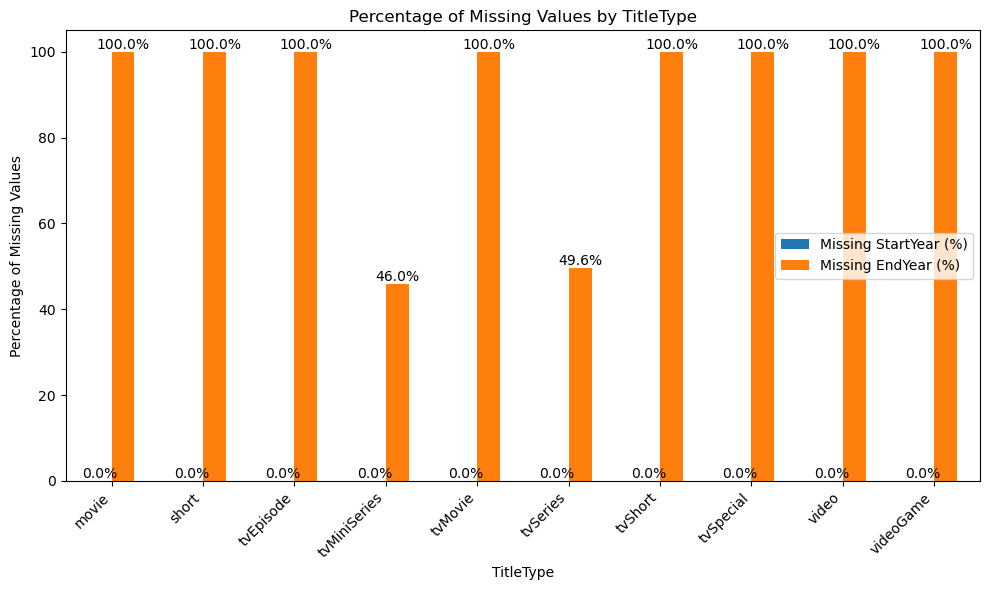

Missing values in 'startYear': 0 (0.00%)
Missing values in 'endYear': 5205 (95.02%)


/tmp/ipykernel_40386/551733678.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


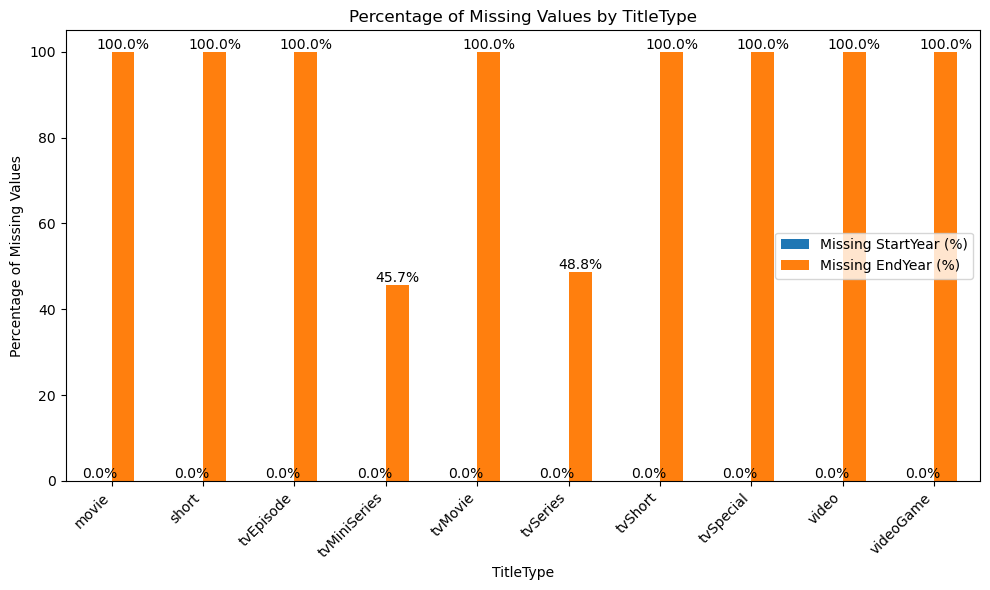

In [38]:
def analyze_missing_years(data):
    """
    Analyze missing values in the 'startYear' and 'endYear' columns and display the percentage of missing values grouped by 'titleType'.

    Args:
        data (pd.DataFrame): The input dataset containing 'startYear', 'endYear', and 'titleType' columns.
    """
    # Replace '\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Check missing values in 'startYear' and 'endYear'
    missing_start_year = data['startYear'].isna().sum()
    missing_end_year = data['endYear'].isna().sum()

    total_rows = len(data)
    missing_start_year_pct = (missing_start_year / total_rows) * 100
    missing_end_year_pct = (missing_end_year / total_rows) * 100

    print(f"Missing values in 'startYear': {missing_start_year} ({missing_start_year_pct:.2f}%)")
    print(f"Missing values in 'endYear': {missing_end_year} ({missing_end_year_pct:.2f}%)")

    # Calculate the percentage of missing values for each 'titleType'
    grouped_missing = data.groupby('titleType').apply(
        lambda x: {
            'missing_startYear': x['startYear'].isna().mean() * 100,
            'missing_endYear': x['endYear'].isna().mean() * 100
        }
    )

    missing_df = pd.DataFrame(grouped_missing.tolist(), index=grouped_missing.index)
    missing_df.columns = ['Missing StartYear (%)', 'Missing EndYear (%)']

    # Plot the data
    ax = missing_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Percentage of Missing Values by TitleType')
    plt.ylabel('Percentage of Missing Values')
    plt.xlabel('TitleType')
    plt.xticks(rotation=45, ha='right')

    # Add percentage labels to the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()

analyze_missing_years(data_train)
analyze_missing_years(data_test)

So the `endYear` is just for `tvMiniSeries` and `tvSeries`.

Let's explore this behaviour:

1. Print a list of `startYear` if `endYear` is missing ordered and without repetition. For each group print also the cardinality of the set.


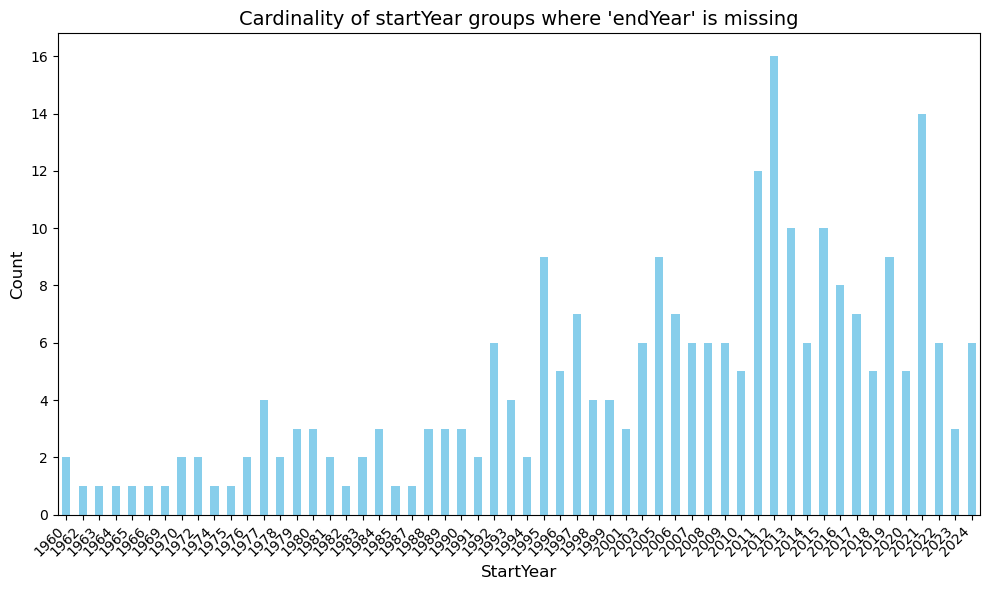

startYear
1960     2
1962     1
1963     1
1964     1
1965     1
1966     1
1969     1
1970     2
1972     2
1974     1
1975     1
1976     2
1977     4
1978     2
1979     3
1980     3
1981     2
1982     1
1983     2
1984     3
1985     1
1987     1
1988     3
1989     3
1990     3
1991     2
1992     6
1993     4
1994     2
1995     9
1996     5
1997     7
1998     4
1999     4
2001     3
2003     6
2005     9
2006     7
2007     6
2008     6
2009     6
2010     5
2011    12
2012    16
2013    10
2014     6
2015    10
2016     8
2017     7
2018     5
2019     9
2020     5
2021    14
2022     6
2023     3
2024     6
dtype: int64


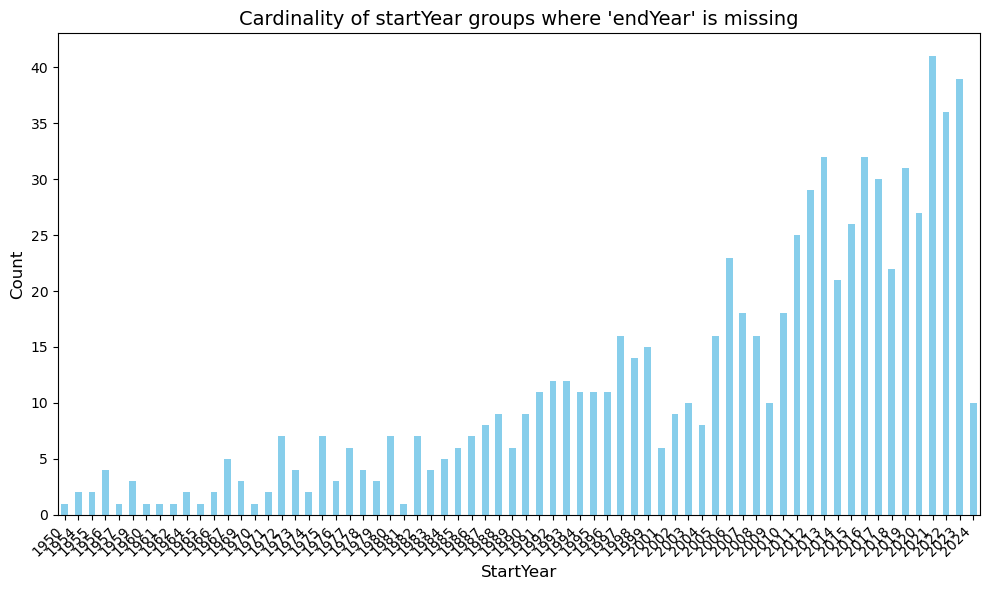

startYear
1950     1
1954     2
1955     2
1956     4
1957     1
        ..
2020    27
2021    41
2022    36
2023    39
2024    10
Length: 68, dtype: int64


In [39]:
def explore_end_year_behavior(data):
    """
    Explore the behavior of 'endYear' focusing on missing values for 'tvSeries' and 'tvMiniSeries'.

    Args:
        data (pd.DataFrame): The input dataset containing 'startYear', 'endYear', and 'titleType' columns.
    """
    # Replace '\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Convert startYear and endYear to numeric for calculations
    data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
    data['endYear'] = pd.to_numeric(data['endYear'], errors='coerce')

    # Filter only tvSeries and tvMiniSeries
    filtered_data = data[data['titleType'].isin(['tvSeries', 'tvMiniSeries'])]

    # Calculate the cardinality of the set for each group
    grouped_start_years = filtered_data[filtered_data['endYear'].isna()].groupby('startYear').size()

    # Plot the results
    plt.figure(figsize=(10, 6))
    grouped_start_years.sort_index().plot(kind='bar', color='skyblue')
    plt.title("Cardinality of startYear groups where 'endYear' is missing", fontsize=14)
    plt.xlabel("StartYear", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(grouped_start_years)

explore_end_year_behavior(data_test)
explore_end_year_behavior(data_train)



There is no clear behaviour for missing values.

It can be assumed that increasng number for most recent year is due the fact that some tvSeries or tvMiniSeries are not finished, but we can't be sure, so we just decided to remove the column.

In [40]:
data_test.drop('endYear', axis=1, inplace=True)
data_train.drop('endYear', axis=1, inplace=True)

#### runTimeMinutes
Let's check the percentage of missing values (`\N`) and then, as we did for `startYear` and `endYear` we plot it for cathegories. 

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


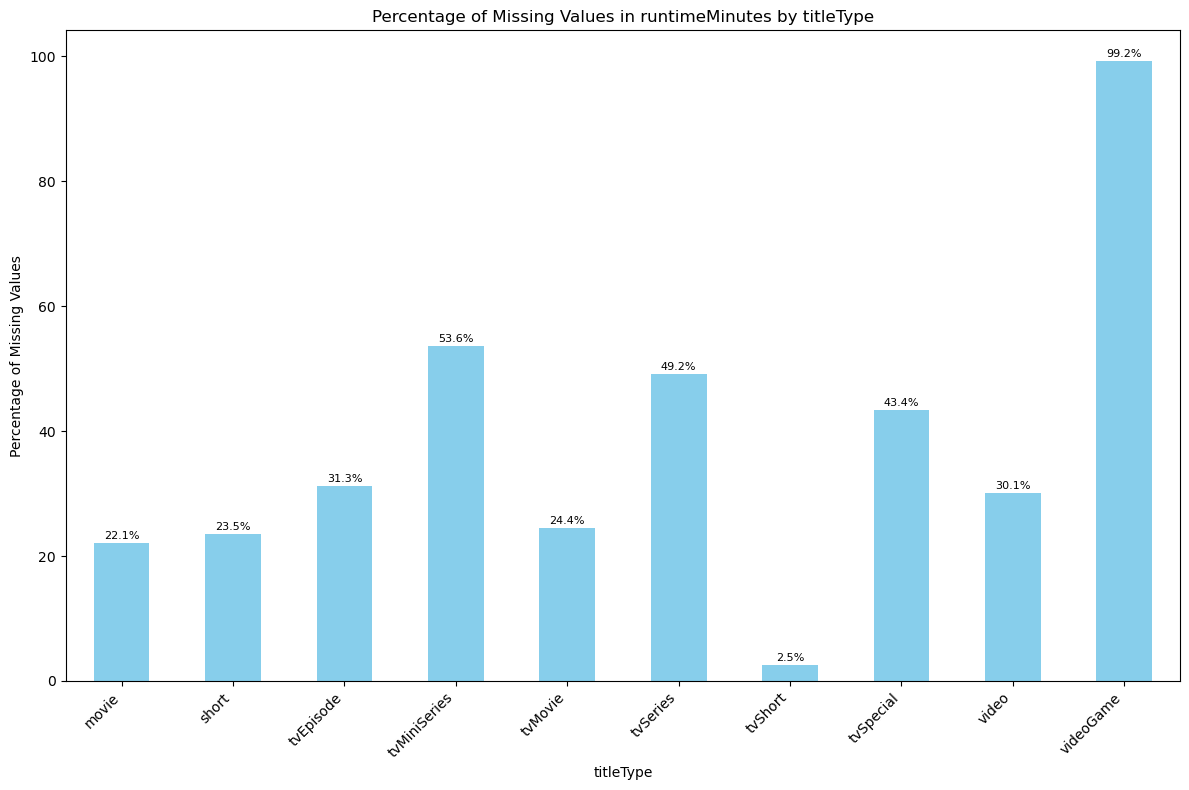

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


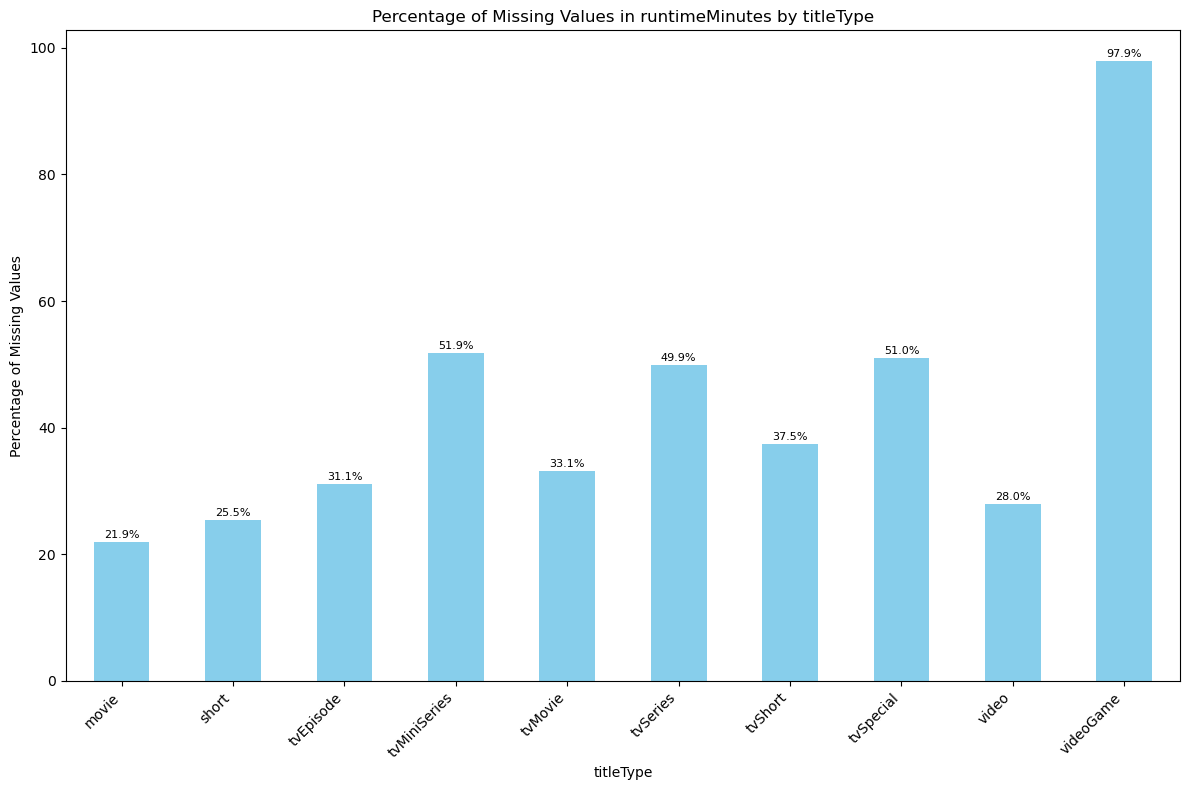

In [41]:
def analyze_missing_values(data, column_to_analyze, group_by_column):
    """
    Analyze missing values ('\\N') in a specific column and display the percentage of missing values grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing various columns.
        column_to_analyze (str): The column to analyze for missing values.
        group_by_column (str): The column to group by when calculating missing values.
    """
    # Replace '\\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Ensure the columns exist in the dataset
    if column_to_analyze not in data.columns:
        raise ValueError(f"Column '{column_to_analyze}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Calculate the percentage of missing values for the specified column grouped by the group_by_column
    grouped_missing = data.groupby(group_by_column).apply(
        lambda x: x[column_to_analyze].isna().mean() * 100
    )

    # Plot the data
    grouped_missing.plot(kind='bar', figsize=(12, 8), color="skyblue")
    plt.title(f'Percentage of Missing Values in {column_to_analyze} by {group_by_column}')
    plt.ylabel('Percentage of Missing Values')
    plt.xlabel(group_by_column)
    plt.xticks(rotation=45, ha='right')

    # Add percentage labels to the bars
    for p in plt.gca().patches:
        if p.get_height() > 0:  # Only annotate non-zero bars
            plt.gca().annotate(f'{p.get_height():.1f}%', 
                               (p.get_x() + p.get_width() / 2., p.get_height()), 
                               ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                               textcoords='offset points')

    plt.tight_layout()
    plt.show()

# Example usage
analyze_missing_values(data_train, 'runtimeMinutes', 'titleType')
analyze_missing_values(data_test, 'runtimeMinutes', 'titleType')


In this case we have a lot of missing values.

In order to manage it properly we will fill the missing values with the median of the runtimeMinutes column grouped by titleType.

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


Missing values in 'runtimeMinutes' filled successfully.
Missing values in 'runtimeMinutes' filled successfully.


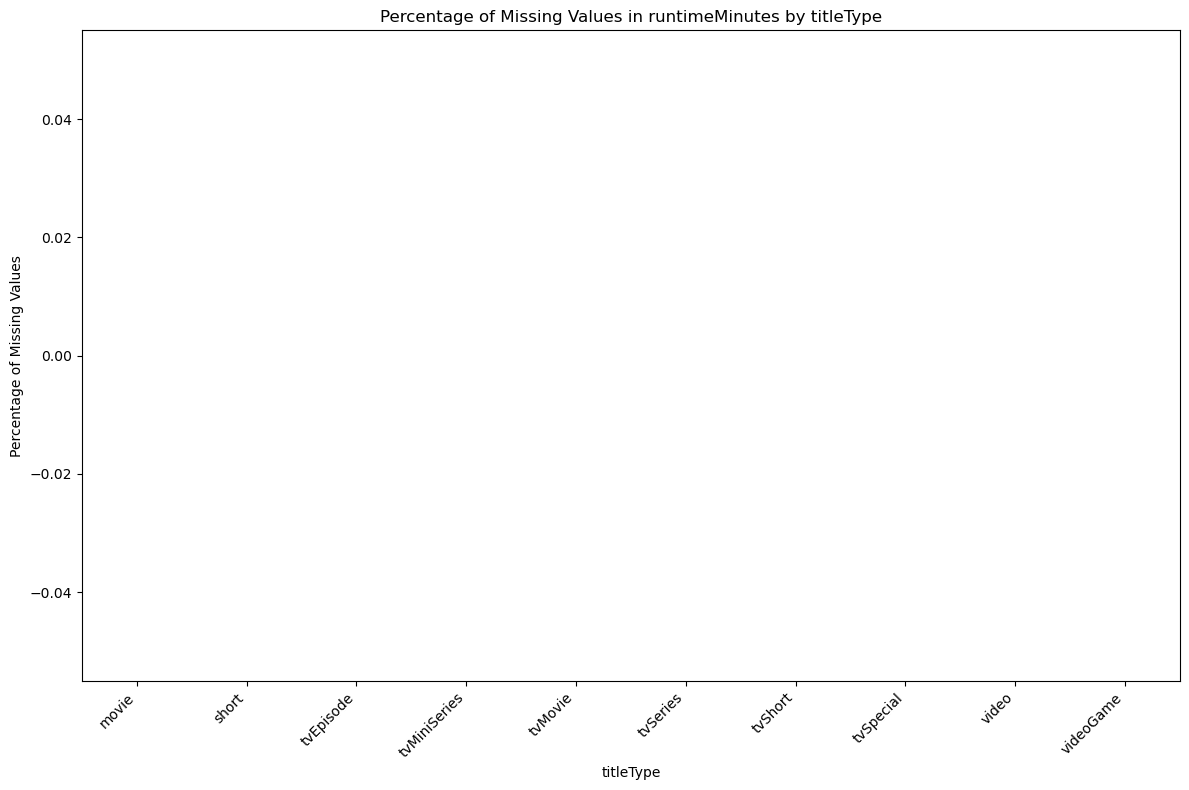

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


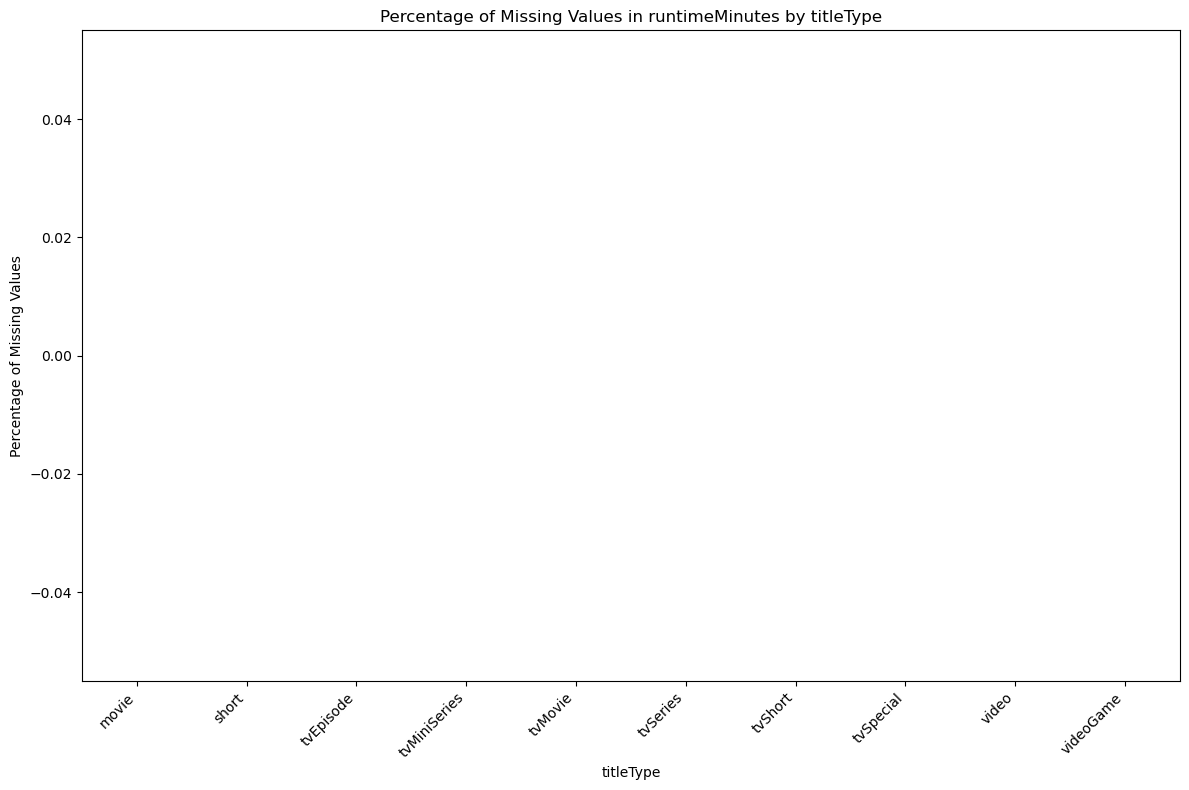

In [42]:
def fill_missing_values(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specific column with the median value grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing various columns.
        column_to_fill (str): The column to fill missing values.
        group_by_column (str): The column to group by when filling missing values.
    """
    # Replace '\\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Convert the column to fill to numeric (if not already)
    data[column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')

    # Fill missing values with the median value grouped by the group_by_column
    data[column_to_fill] = data.groupby(group_by_column)[column_to_fill].transform(
        lambda x: x.fillna(x.median())
    )

    print(f"Missing values in '{column_to_fill}' filled successfully.")

# Example usage
fill_missing_values(data_train, 'runtimeMinutes', 'titleType')
fill_missing_values(data_test, 'runtimeMinutes', 'titleType')

analyze_missing_values(data_train, 'runtimeMinutes', 'titleType')
analyze_missing_values(data_test, 'runtimeMinutes', 'titleType')

#### awardWins
As before we check for missing values

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


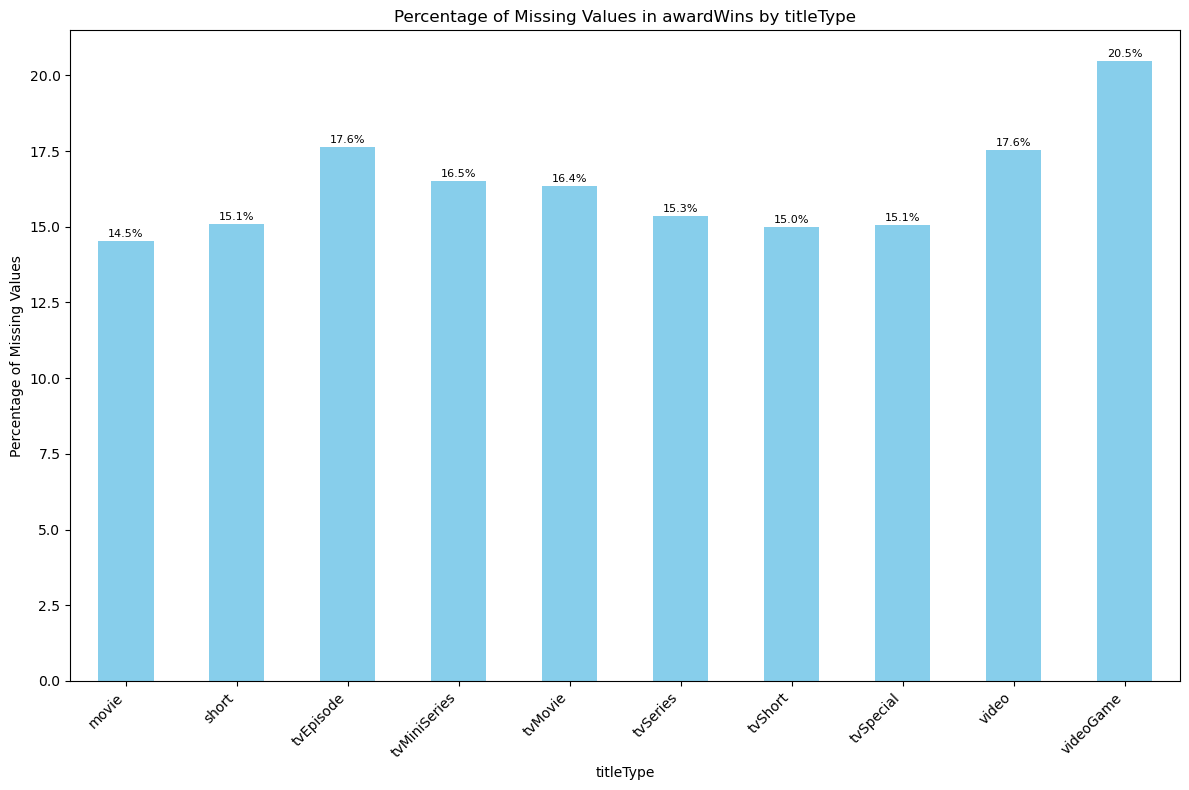

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


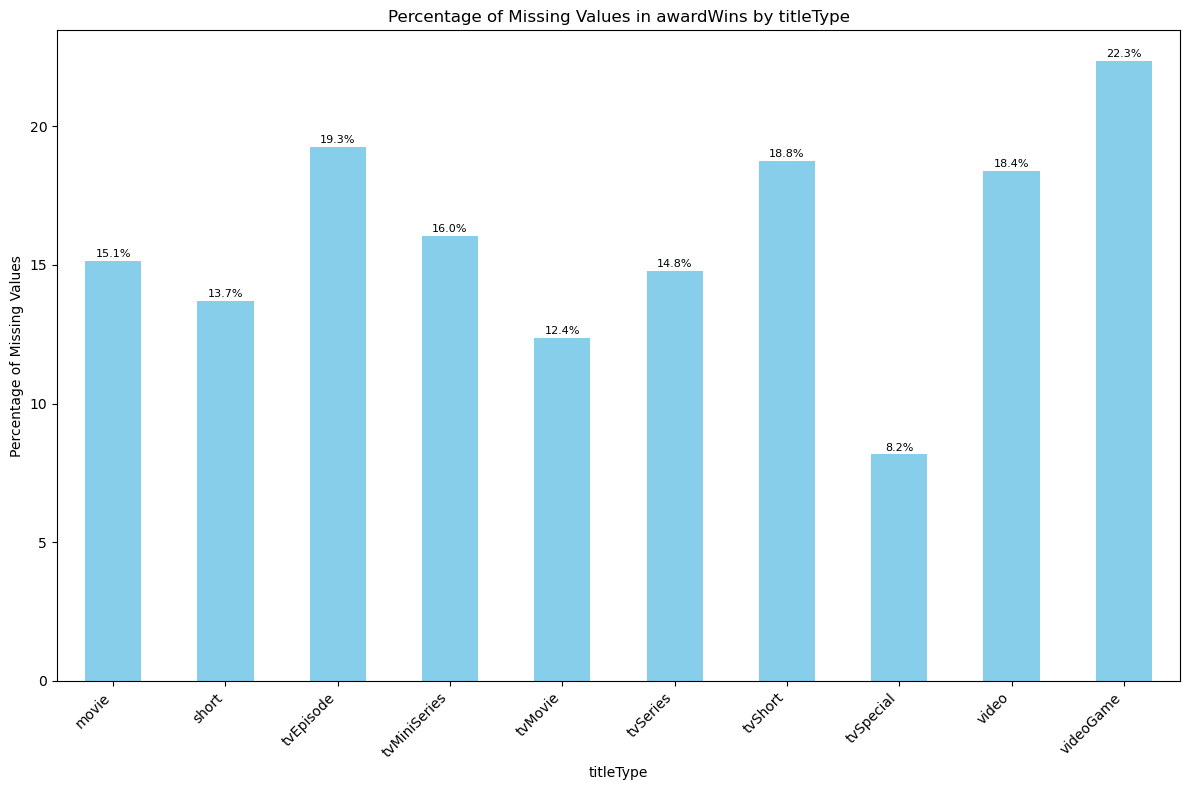

In [43]:
analyze_missing_values(data_train, 'awardWins', 'titleType')
analyze_missing_values(data_test, 'awardWins', 'titleType')

In this case missing values are managed adding a special value (-1).

In [44]:
def fill_missing_values_with_nan(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specific column with NaN, grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing various columns.
        column_to_fill (str): The column to fill missing values.
        group_by_column (str): The column to group by when filling missing values.
    """
    # Replace '\\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Convert the column to fill to numeric (if not already)
    data[column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')

    # Ensure that NaN values are explicitly set
    data[column_to_fill] = data[column_to_fill].where(data[column_to_fill].notna(), np.nan)

    print(f"Missing values in '{column_to_fill}' replaced with NaN successfully.")


# Example usage
fill_missing_values_with_nan(data_train, 'awardWins', 'titleType')
fill_missing_values_with_nan(data_test, 'awardWins', 'titleType')

Missing values in 'awardWins' replaced with NaN successfully.
Missing values in 'awardWins' replaced with NaN successfully.


#### numVotes
Same work as before

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


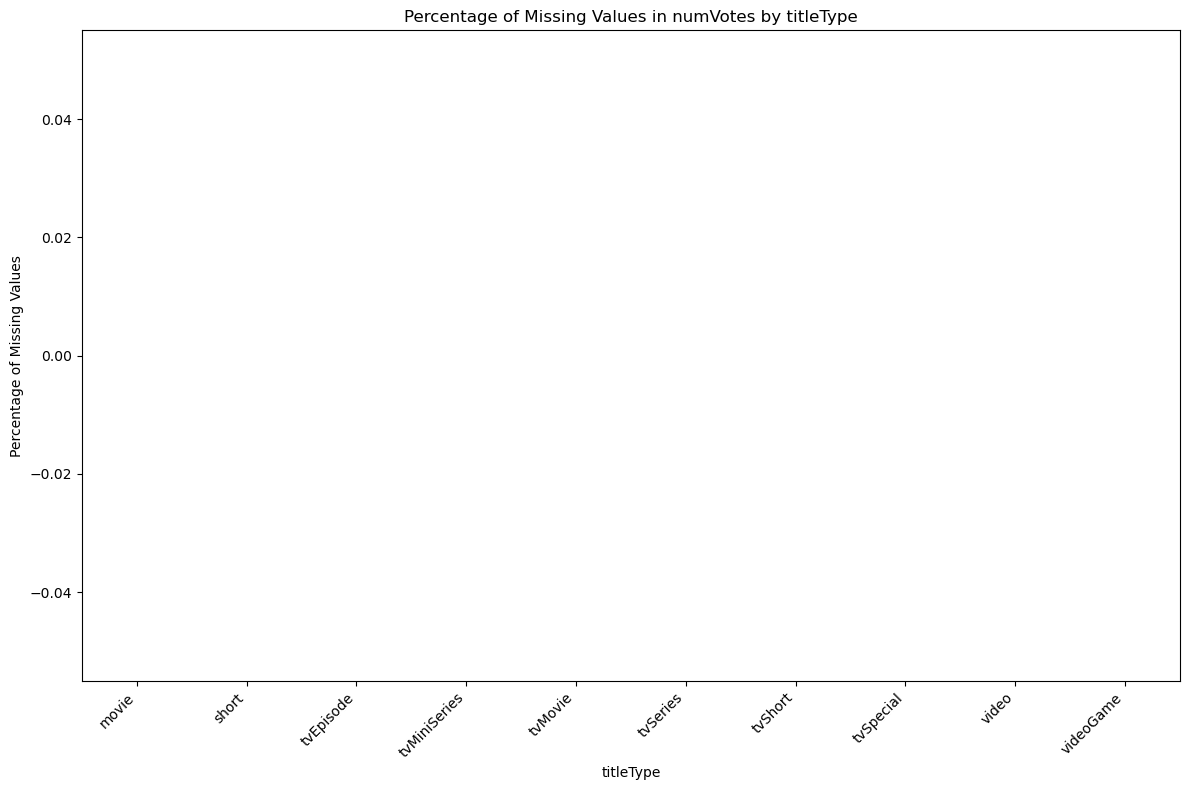

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


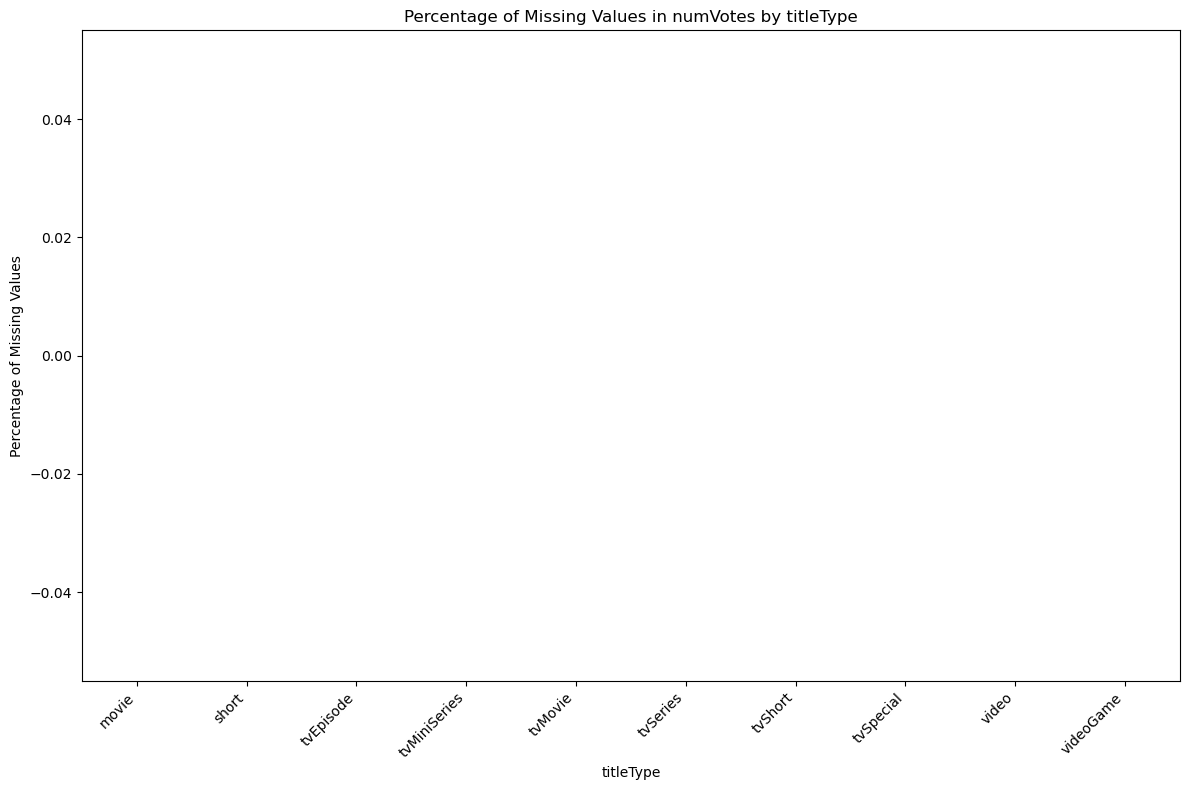

In [45]:
analyze_missing_values(data_train, 'numVotes', 'titleType')
analyze_missing_values(data_test, 'numVotes', 'titleType')


#### `worstRating` and `bestRating`
These are dummy columns, we just drop them

In [46]:
data_test.drop('worstRating', axis=1, inplace=True)
data_train.drop('worstRating', axis=1, inplace=True)

data_test.drop('bestRating', axis=1, inplace=True)
data_train.drop('bestRating', axis=1, inplace=True)

#### `totalImages`, `totalVideos` and `totalCredits`
As done before, let's check for this columns if there are missing values

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


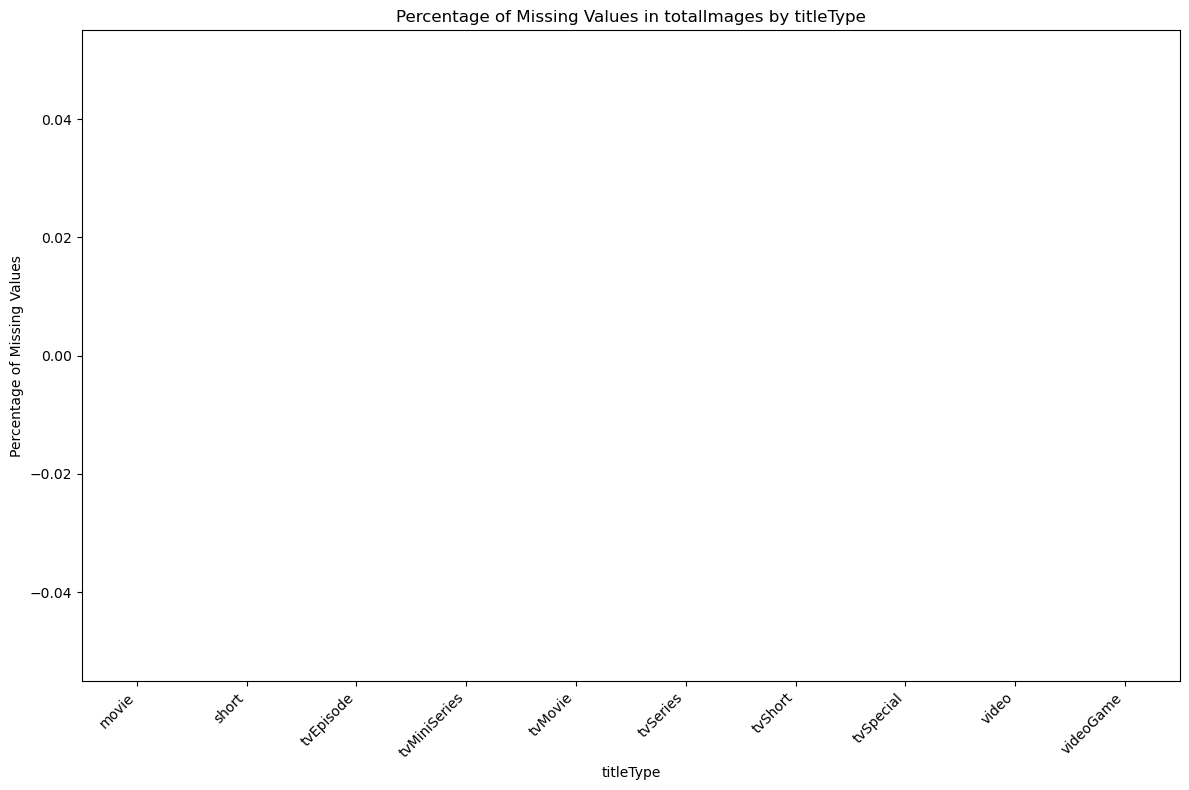

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


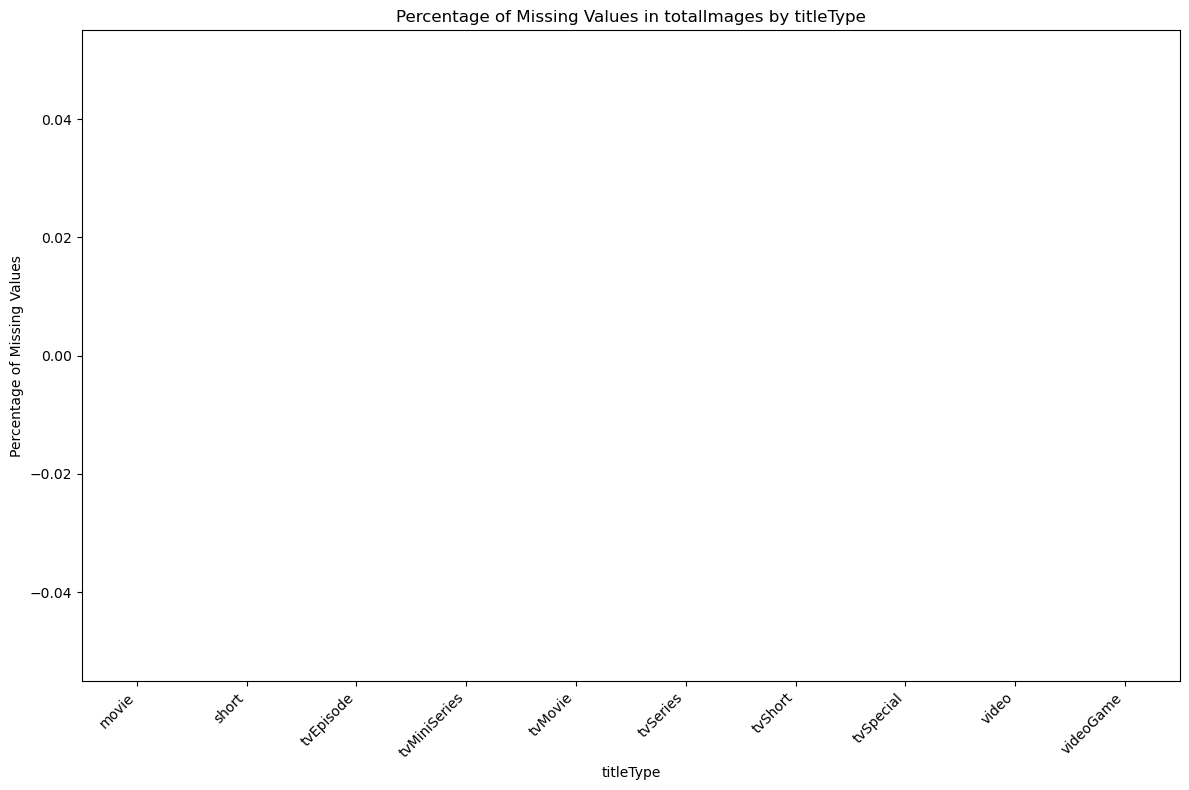

In [47]:
analyze_missing_values(data_train, 'totalImages', 'titleType')
analyze_missing_values(data_test, 'totalImages', 'titleType')

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


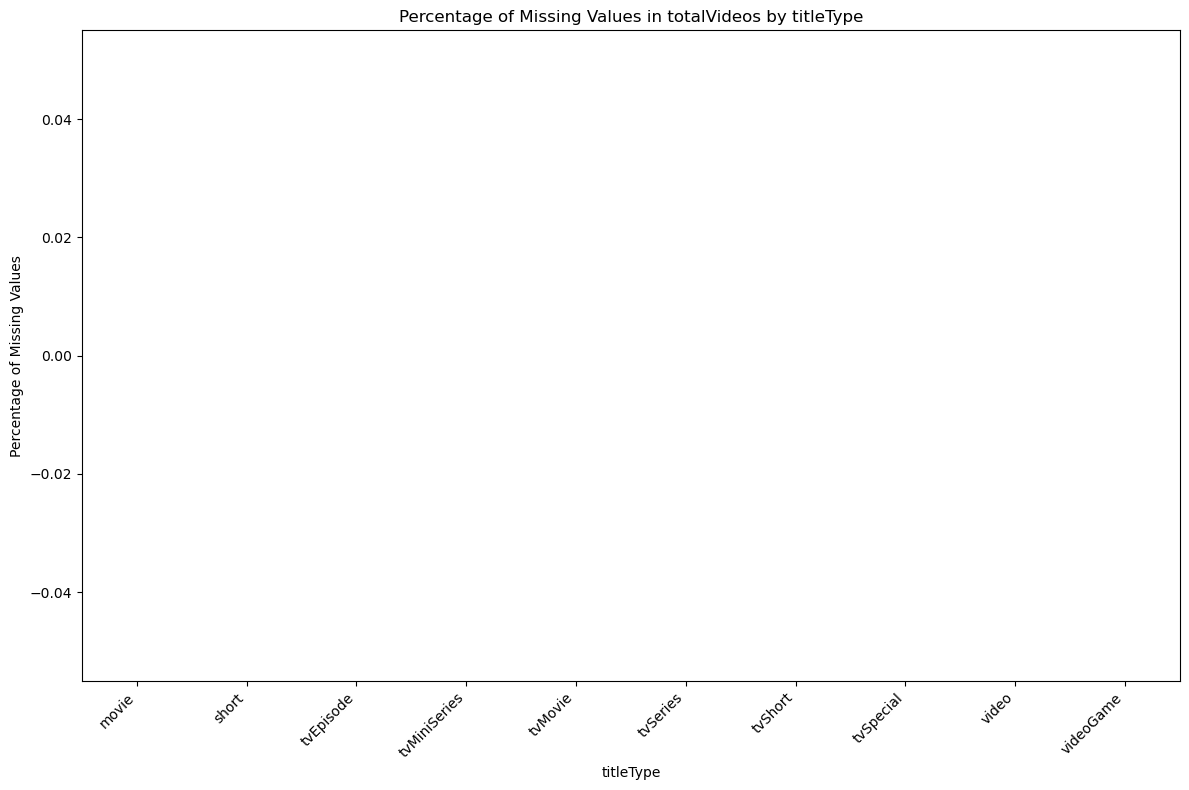

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


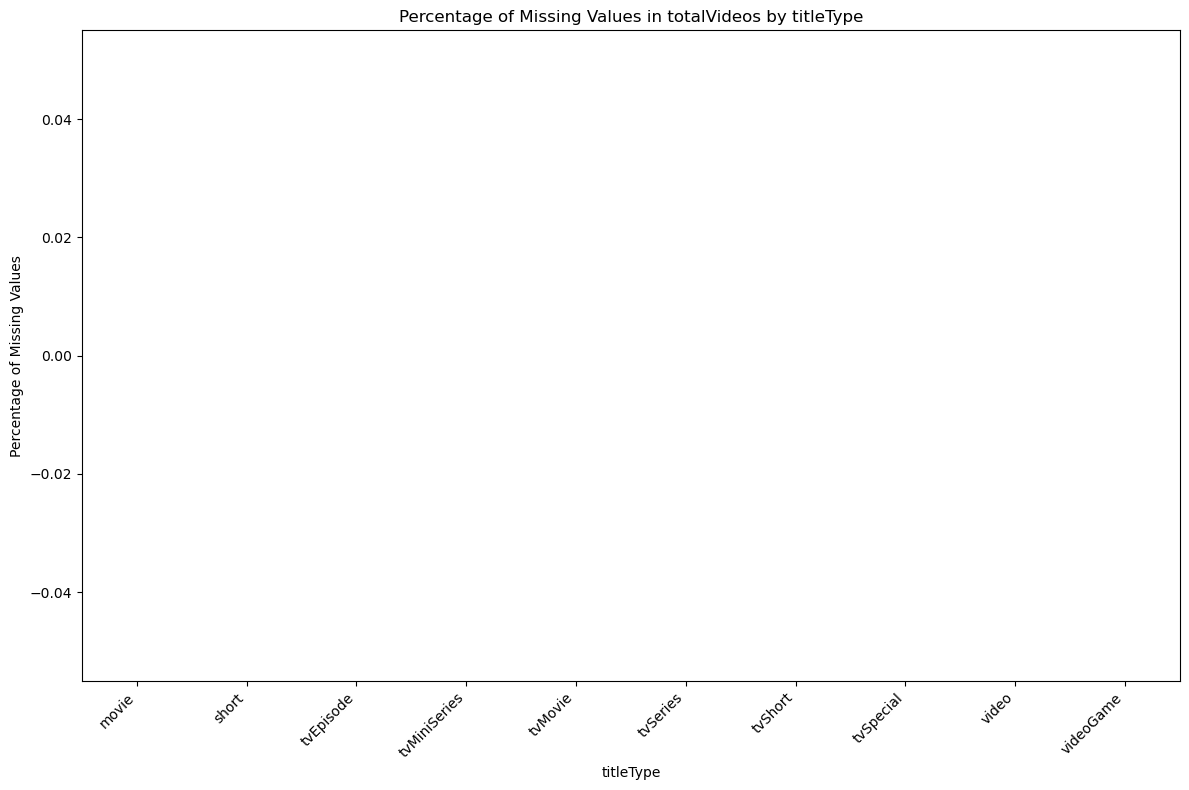

In [48]:
analyze_missing_values(data_train, 'totalVideos', 'titleType')
analyze_missing_values(data_test, 'totalVideos', 'titleType')

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


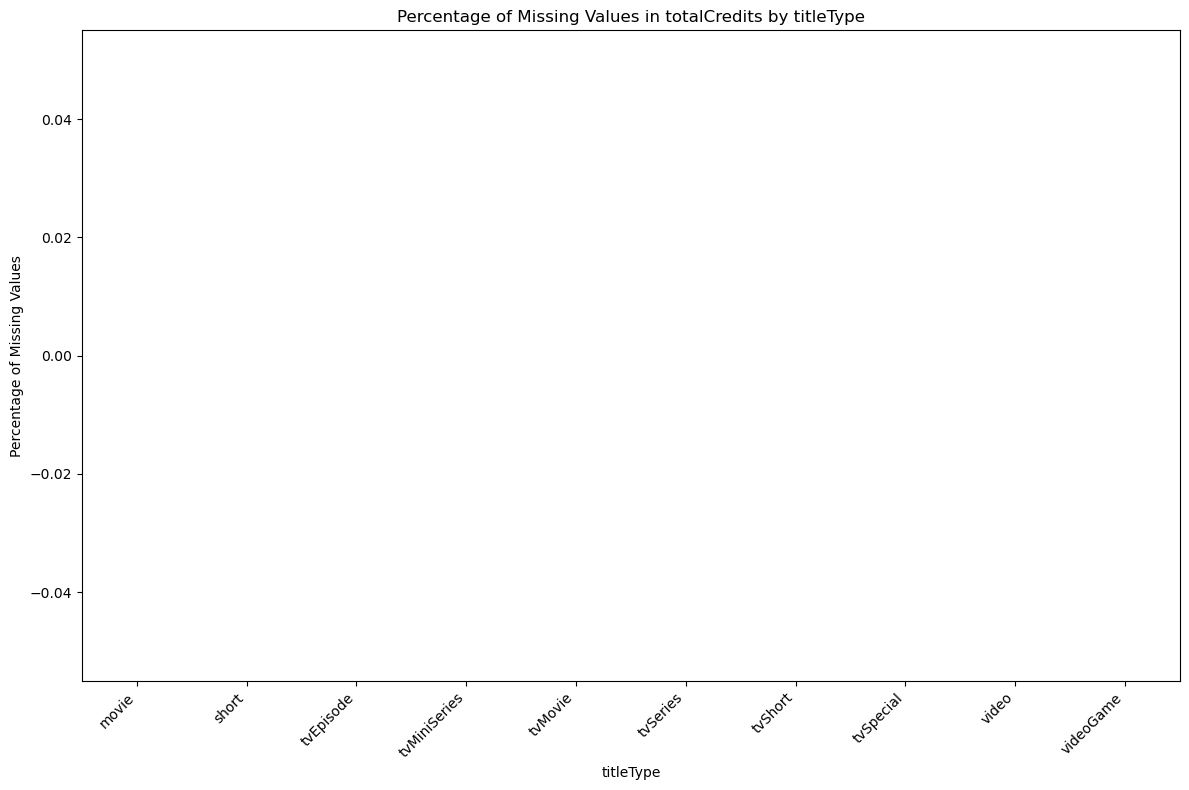

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


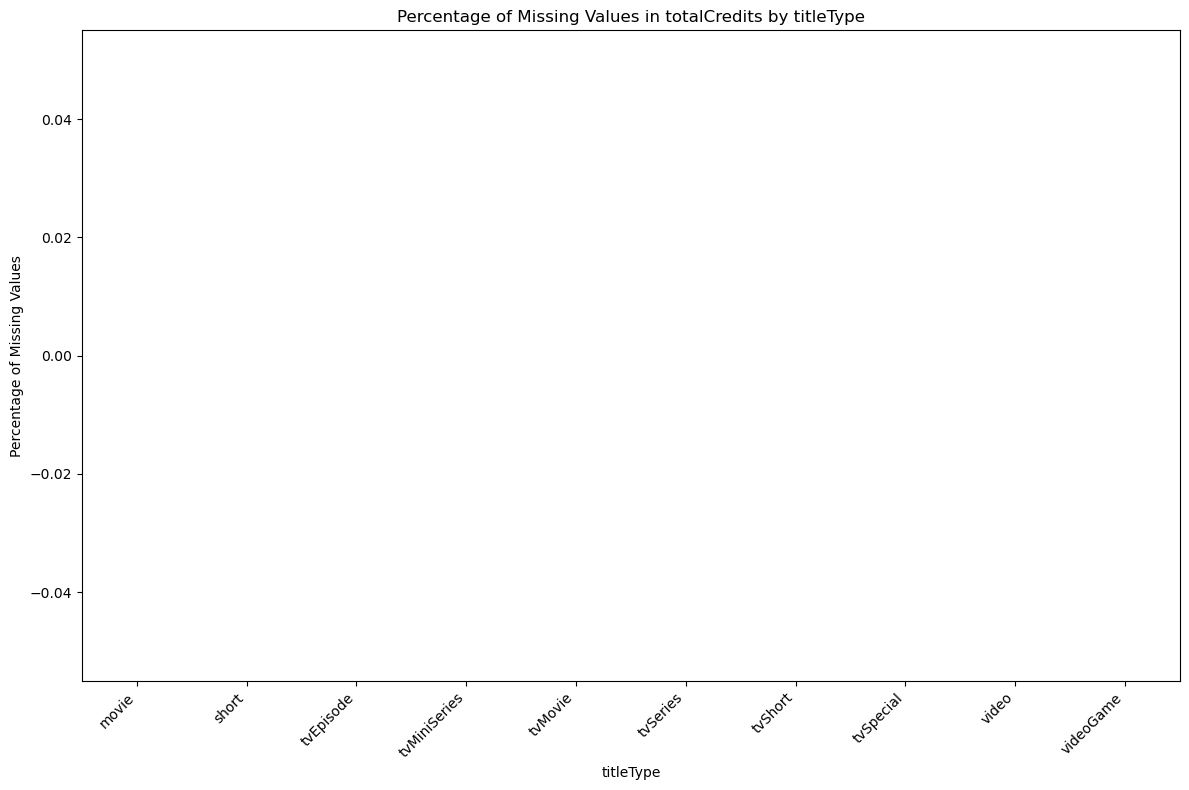

In [49]:
analyze_missing_values(data_train, 'totalCredits', 'titleType')
analyze_missing_values(data_test, 'totalCredits', 'titleType')

as we can see, there are no missing values, so everything is fine.

#### CriticReviewsTotal
First of all we check missing values

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


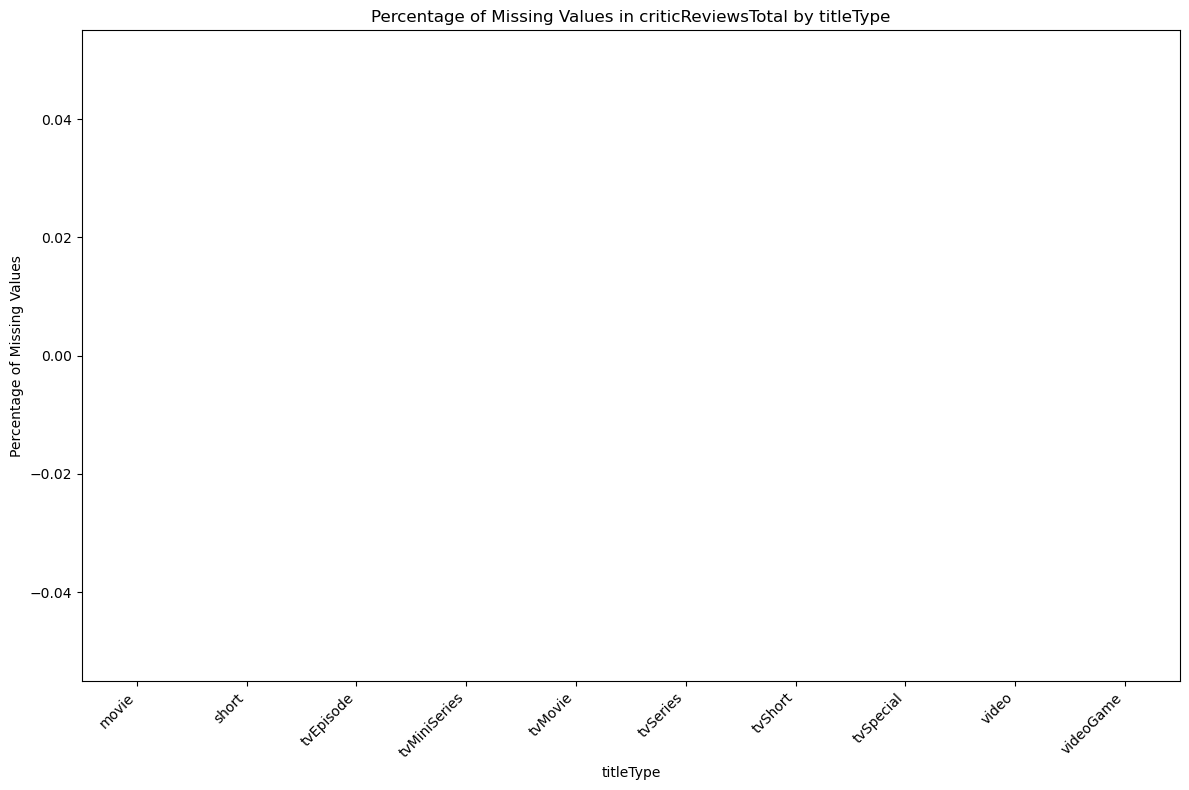

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


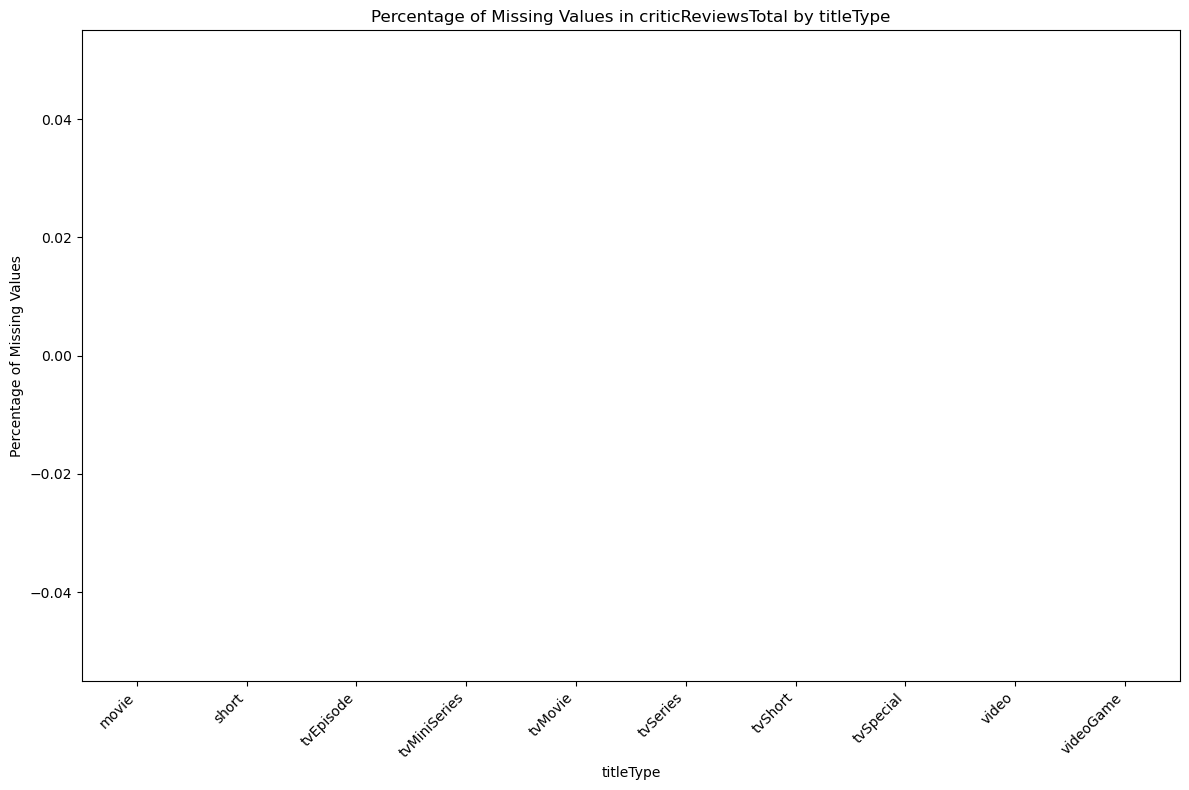

In [50]:
analyze_missing_values(data_train, 'criticReviewsTotal', 'titleType')
analyze_missing_values(data_test, 'criticReviewsTotal', 'titleType')

#### titleType
Plot the number of element in the dataset groupedBy title type and plot the percentage of missing values in another plot always groupedBy title and only of this column

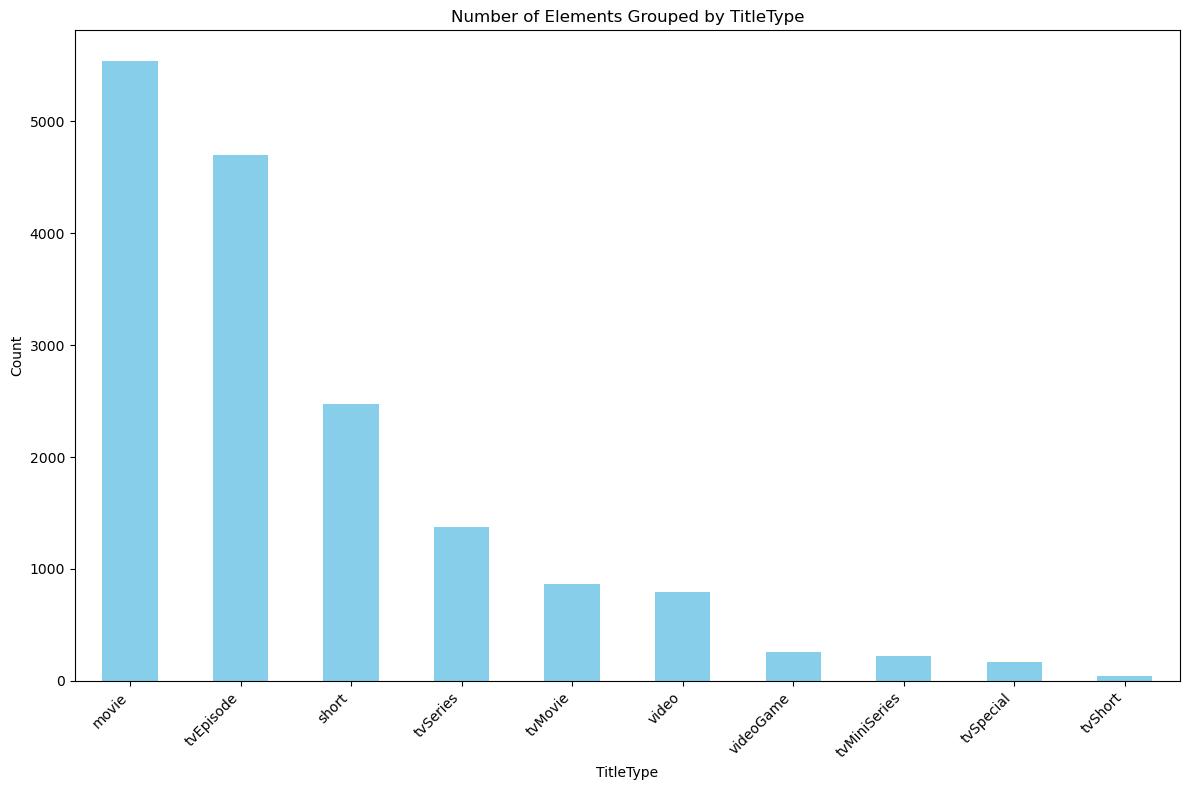

/tmp/ipykernel_40386/868400090.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


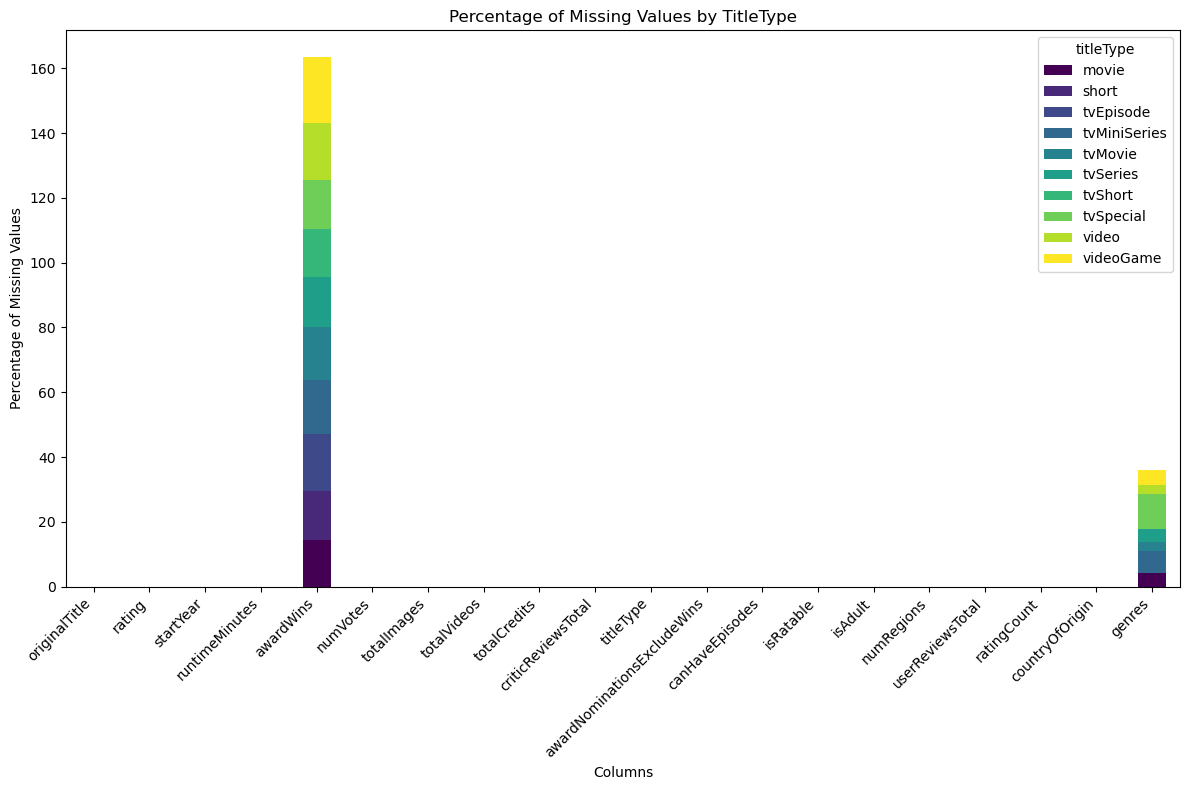

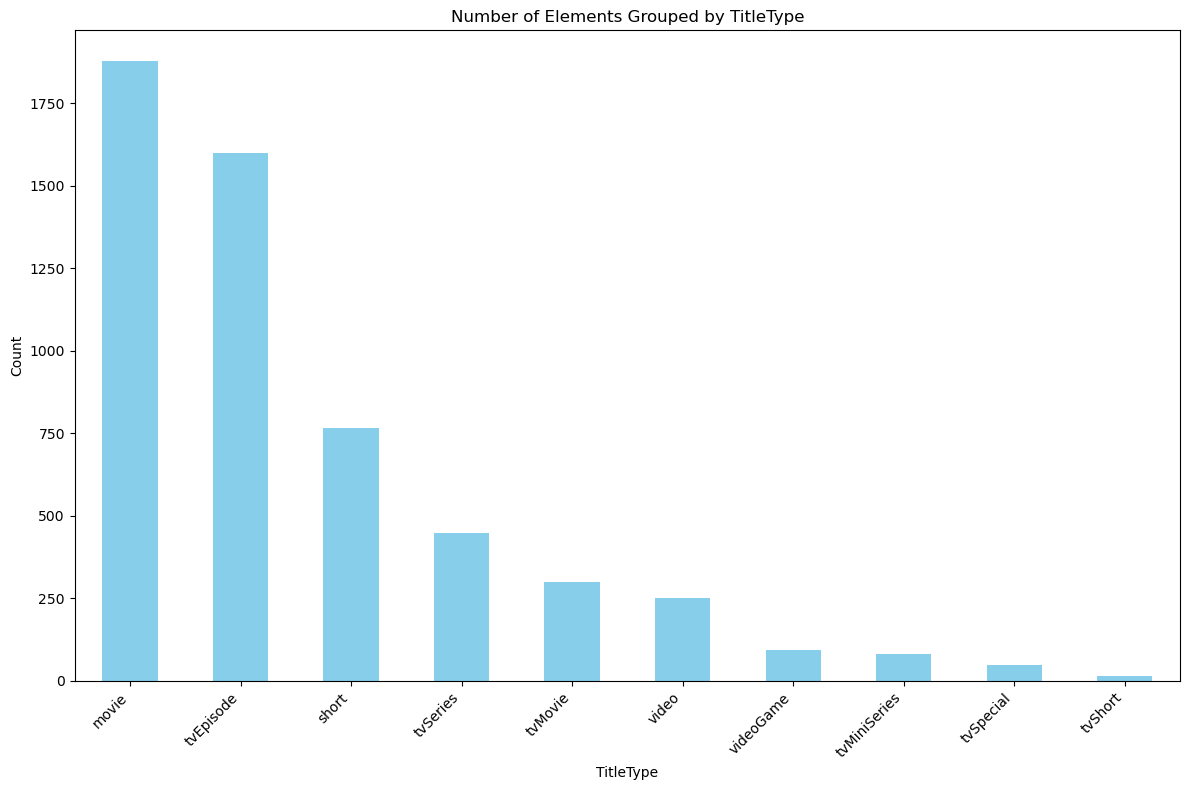

/tmp/ipykernel_40386/868400090.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


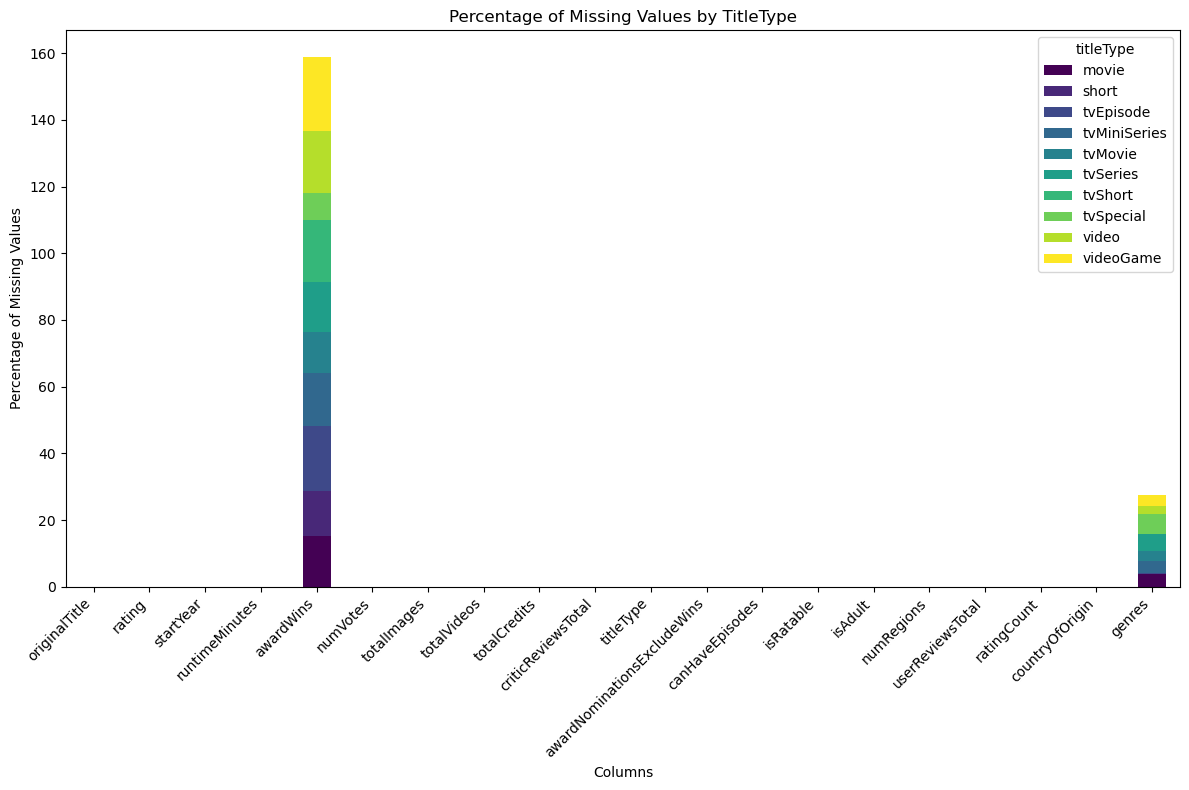

In [51]:
def plot_title_type_analysis(data):
    """
    Plot the number of elements in the dataset grouped by title type and the percentage of missing values.

    Args:
        data (pd.DataFrame): The input dataset containing a 'titleType' column and various other columns.
    """
    # Replace '\\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Ensure the 'titleType' column exists in the dataset
    if 'titleType' not in data.columns:
        raise ValueError("Column 'titleType' not found in the dataset.")

    # Plot the number of elements grouped by title type
    title_type_counts = data['titleType'].value_counts()
    plt.figure(figsize=(12, 8))
    title_type_counts.plot(kind='bar', color="skyblue")
    plt.title('Number of Elements Grouped by TitleType')
    plt.ylabel('Count')
    plt.xlabel('TitleType')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Calculate the percentage of missing values for each title type
    missing_percentages = data.isna().mean() * 100
    grouped_missing = data.groupby('titleType').apply(
        lambda x: x.isna().mean() * 100
    )

    # Plot the percentage of missing values
    grouped_missing.T.plot(kind='bar', figsize=(12, 8), stacked=True, colormap="viridis")
    plt.title('Percentage of Missing Values by TitleType')
    plt.ylabel('Percentage of Missing Values')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

# Example usage
plot_title_type_analysis(data_train)
plot_title_type_analysis(data_test)

#### awardNominationsExcludeWins

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


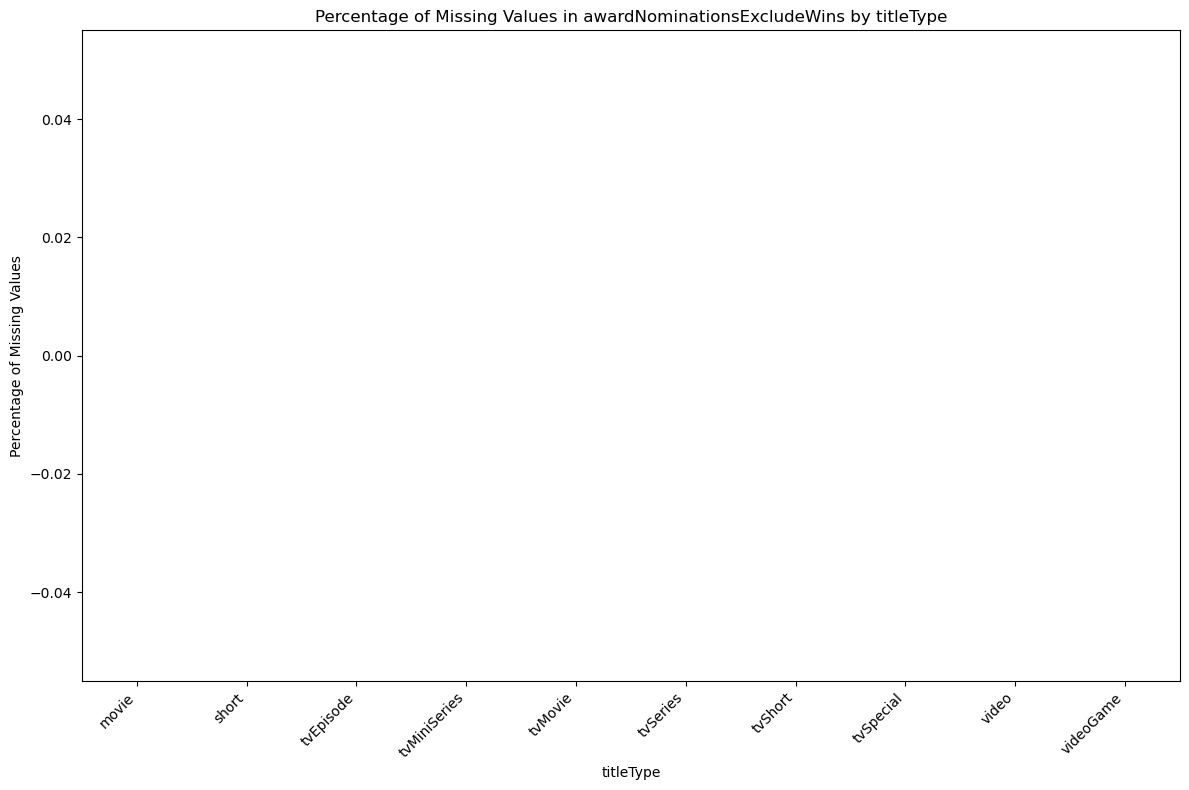

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


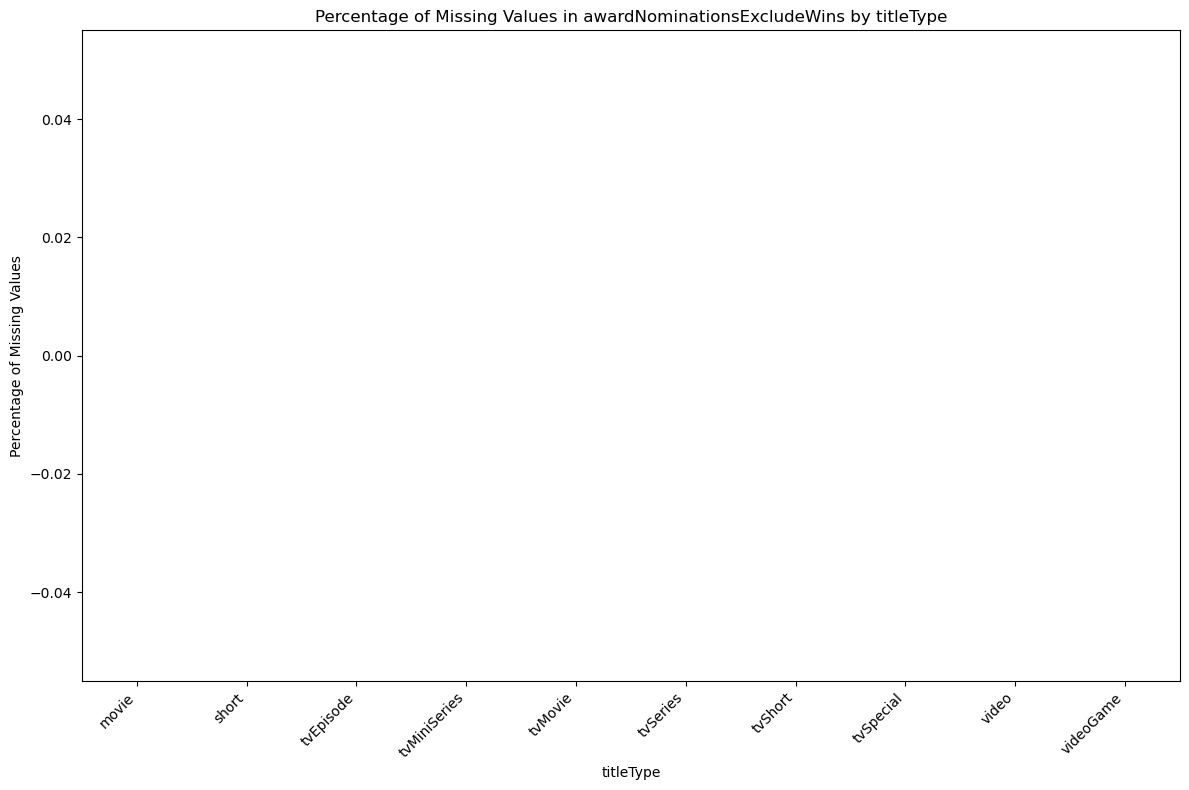

In [52]:
analyze_missing_values(data_train, 'awardNominationsExcludeWins', 'titleType')
analyze_missing_values(data_test, 'awardNominationsExcludeWins', 'titleType')

#### `isRatable`, `canHaveEpisodes` and `isAdult`

- `isRatable` is just removed
- `canHaveEpisode` is mantained
- `isAdult` cast to bool


In [53]:
# Remove `isRatable` column
if 'isRatable' in data_train.columns:
    data_train.drop(columns='isRatable', inplace=True)
if 'isRatable' in data_test.columns:
    data_test.drop(columns='isRatable', inplace=True)

# Cast `isAdult` to boolean
if 'isAdult' in data_train.columns:
    data_train['isAdult'] = data_train['isAdult'].astype(bool)
if 'isAdult' in data_test.columns:
    data_test['isAdult'] = data_test['isAdult'].astype(bool)

print("Columns refactored successfully.")

Columns refactored successfully.


#### numRegions 
Everything's fine

#### `userReviewTotal` and `ratingCount`
We check for missing values

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


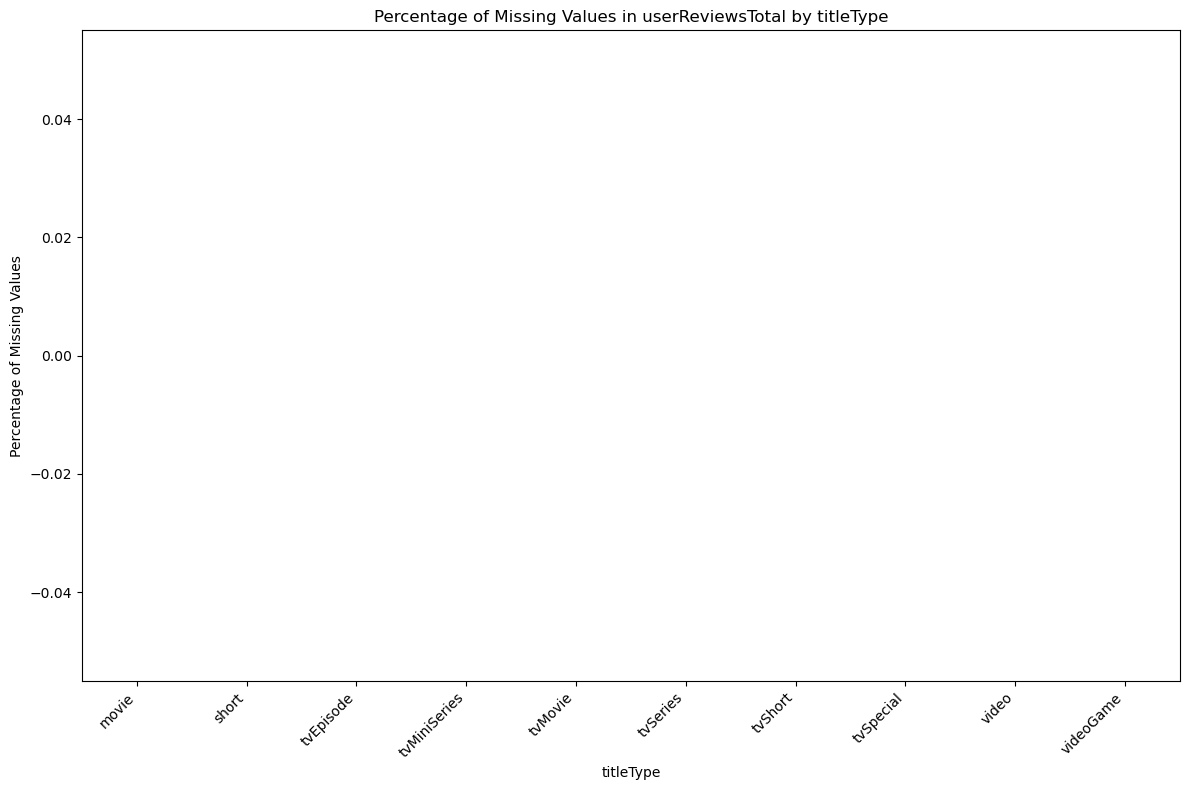

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


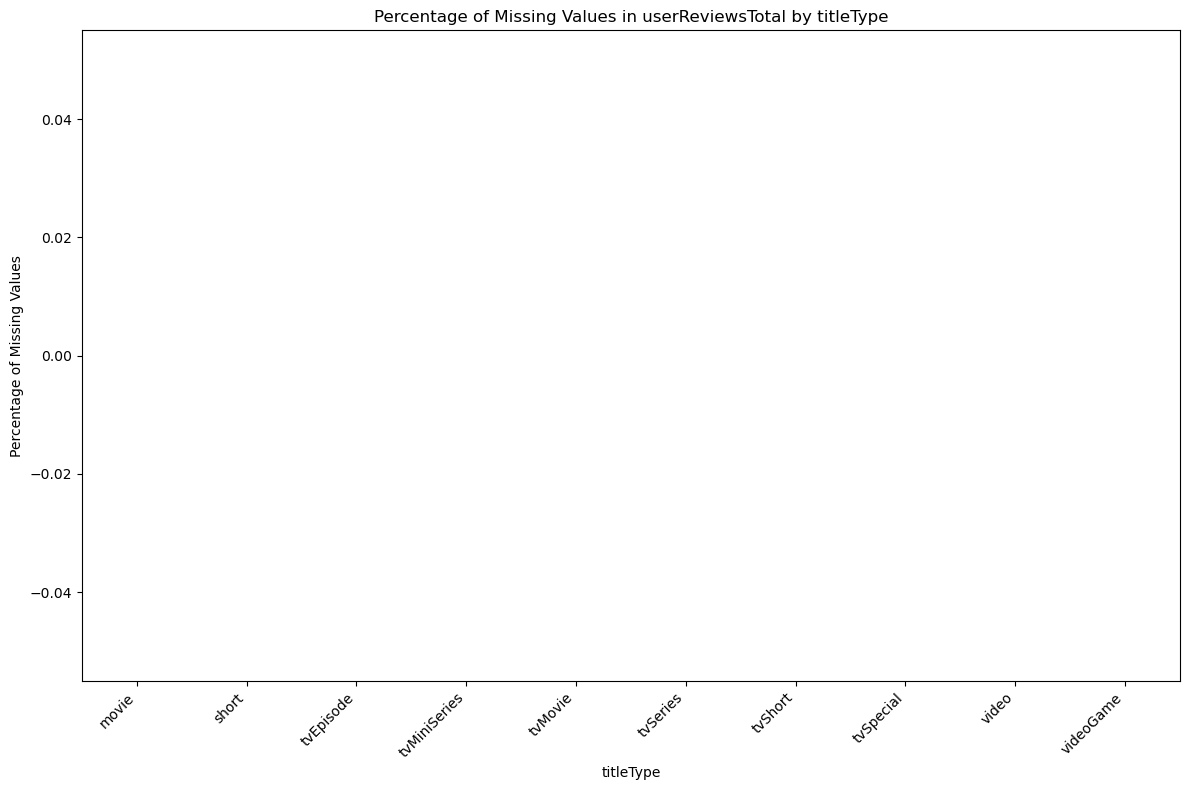

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


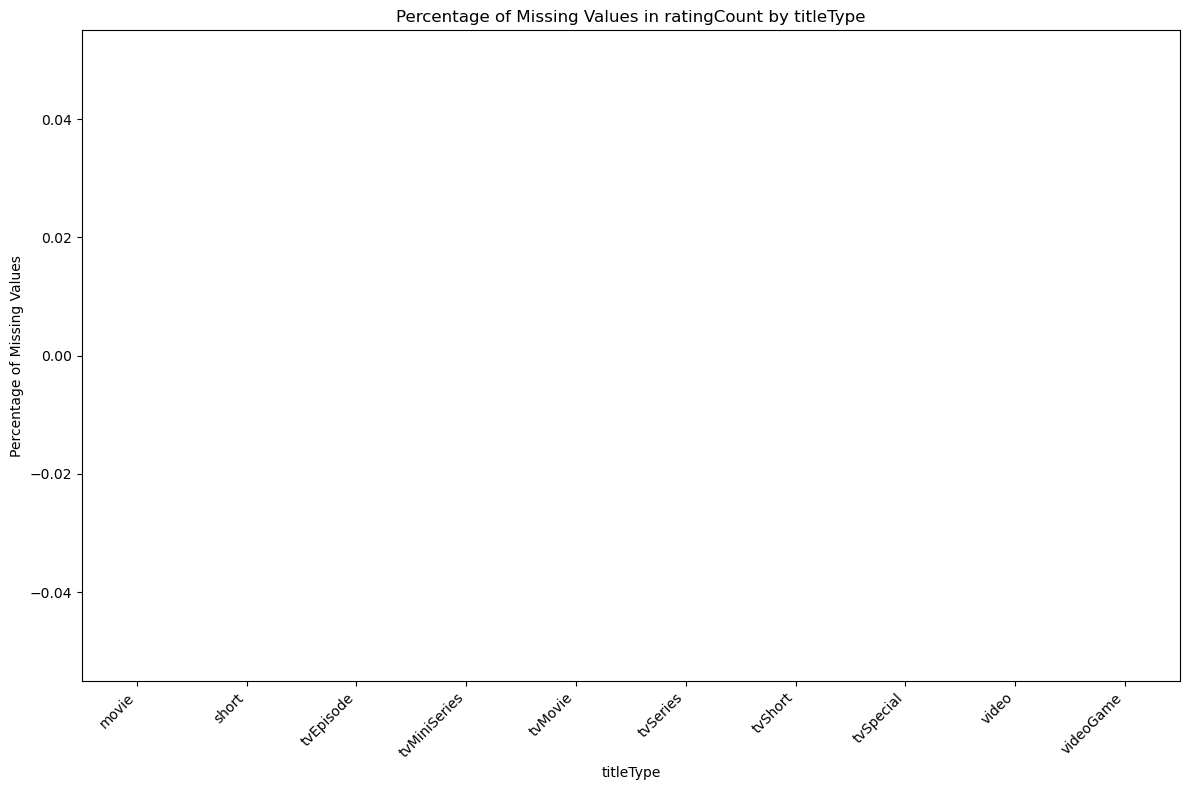

/tmp/ipykernel_40386/3270939085.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


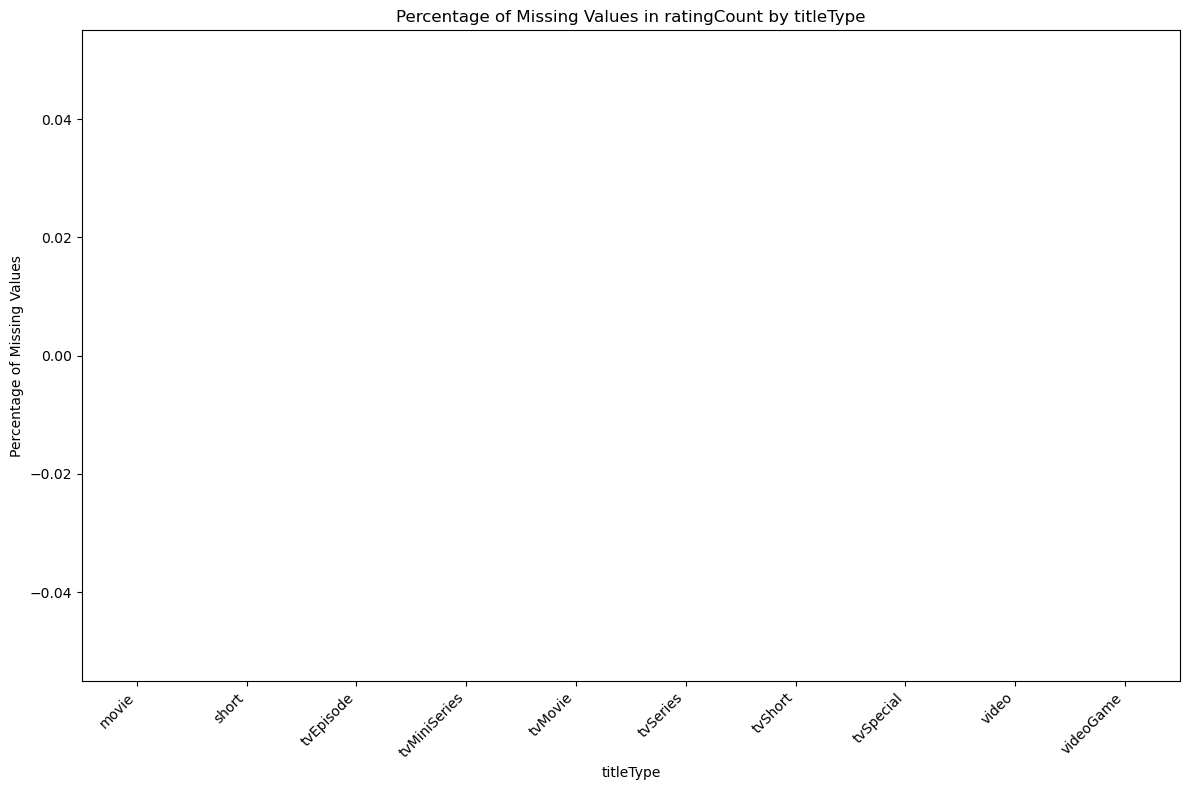

In [54]:
analyze_missing_values(data_train, 'userReviewsTotal', 'titleType')
analyze_missing_values(data_test, 'userReviewsTotal', 'titleType')
analyze_missing_values(data_train, 'ratingCount', 'titleType')
analyze_missing_values(data_test, 'ratingCount', 'titleType')

# New column `nominations`
1. `Nominations = Award wins + AwardNominations excluded wins` if there is a missing value in one of the original columns, then the values is set to `-1`


In [55]:
def add_nominations_column(data):
    """
    Add a new column `Nominations` computed as:
    Nominations = awardWins + awardNominationsExcludeWins.
    If either value is missing, set `Nominations` to -1.
    
    Parameters:
    - data (pd.DataFrame): The input dataset.
    
    Returns:
    - pd.DataFrame: The updated dataset with the new `Nominations` column.
    """
    
    # Calculate the `Nominations` column
    data['nominations'] = data.apply(
        lambda row: np.nan if row['awardWins'] == -1 or row['awardNominationsExcludeWins'] == -1 
        else row['awardWins'] + row['awardNominationsExcludeWins'], 
        axis=1
    )
    
    return data

data_test = add_nominations_column(data_test)
data_train = add_nominations_column(data_train)

# `titleType` analysis

1. **Print All Possible Values of `titleType`:**  
   Extract and display all unique values present in the `titleType` column to understand its categories.

2. **Print All Unique Pairs `{titleType, canHaveEpisodes}`:**  
   Display all distinct combinations of `titleType` and `canHaveEpisodes` from the dataset to analyze their relationships.

In [56]:
def analyze_title_types(data):
    # Get and sort unique values of `titleType`
    unique_title_types = sorted(data['titleType'].unique())
    print(unique_title_types)

    # Get and sort unique pairs {titleType, canHaveEpisodes}
    unique_pairs = data[['titleType', 'canHaveEpisodes']].drop_duplicates()
    unique_pairs = unique_pairs.sort_values(by=['titleType', 'canHaveEpisodes'])
    print(unique_pairs)

    return unique_title_types, unique_pairs

In [57]:
# data_train
analyze_title_types(data_train)

['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']
        titleType  canHaveEpisodes
2           movie            False
8           short            False
0       tvEpisode            False
7    tvMiniSeries             True
10        tvMovie            False
3        tvSeries             True
287       tvShort            False
11      tvSpecial            False
5           video            False
1       videoGame            False


(['movie',
  'short',
  'tvEpisode',
  'tvMiniSeries',
  'tvMovie',
  'tvSeries',
  'tvShort',
  'tvSpecial',
  'video',
  'videoGame'],
         titleType  canHaveEpisodes
 2           movie            False
 8           short            False
 0       tvEpisode            False
 7    tvMiniSeries             True
 10        tvMovie            False
 3        tvSeries             True
 287       tvShort            False
 11      tvSpecial            False
 5           video            False
 1       videoGame            False)

In [58]:
analyze_title_types(data_test)

['movie', 'short', 'tvEpisode', 'tvMiniSeries', 'tvMovie', 'tvSeries', 'tvShort', 'tvSpecial', 'video', 'videoGame']
        titleType  canHaveEpisodes
1           movie            False
9           short            False
3       tvEpisode            False
96   tvMiniSeries             True
14        tvMovie            False
6        tvSeries             True
164       tvShort            False
2       tvSpecial            False
0           video            False
52      videoGame            False


(['movie',
  'short',
  'tvEpisode',
  'tvMiniSeries',
  'tvMovie',
  'tvSeries',
  'tvShort',
  'tvSpecial',
  'video',
  'videoGame'],
         titleType  canHaveEpisodes
 1           movie            False
 9           short            False
 3       tvEpisode            False
 96   tvMiniSeries             True
 14        tvMovie            False
 6        tvSeries             True
 164       tvShort            False
 2       tvSpecial            False
 0           video            False
 52      videoGame            False)

#### Analysis
There is a correlation between `titleType` and `canHaveEpisodes`. The `canHaveEpisodes` column might be redundant.

# one-hot encoding
This Python code defines a function `process_column` to preprocess a column of a DataFrame by cleaning its values, performing one-hot encoding, and saving metadata about the newly generated columns.

#### Steps in the Function:
1. **Clean the Column**:
   - Ensures the column values are strings.
   - Strips unwanted characters (`[]` and `'`) and splits values into a list.

2. **Add a Count Column**:
   - Creates a new column named dynamically as `NumberOf<ColumnName>`.
   - Stores the count of items in the list for each row.

3. **One-Hot Encoding**:
   - Transforms the column into a one-hot encoded DataFrame by expanding the lists into separate binary columns.

4. **Combine Data**:
   - Merges the one-hot encoded columns back with the original DataFrame.

5. **Save Metadata**:
   - Writes the names of the newly created columns (count column and one-hot encoded columns) to a specified file.

6. **Remove Original Column**:
   - Drops the original column from the DataFrame.

#### `merge_txt_files`
The `merge_txt_files` function merges multiple `.txt` files into a single output file, ensuring no duplicate lines. It reads lines from input files into a set (to remove duplicates), sorts them alphabetically, and writes the result to the specified output file.

- **Removes Duplicates**: Ensures unique lines in the output.
- **Alphabetical Sorting**: Orders lines for consistency.
- **Flexible Input**: Accepts a variable number of input files.


In [59]:
def one_hot_encoding(data, column_name, columns_file, replace_null_with_unknown=False):
    """
    Performs one-hot encoding on a specified column of a DataFrame.

    Args:
        data (pd.DataFrame): Input DataFrame.
        column_name (str): Column to be one-hot encoded.
        columns_file (str): File to save the new column names.
        replace_null_with_unknown (bool): Replace '\\N' with 'unknown<ColumnName>' if True.

    Returns:
        pd.DataFrame: Updated DataFrame with one-hot encoded columns.
    """
    # Ensure the specified column is a string and clean it
    data[column_name] = data[column_name].astype(str)

    # Replace '\N' with 'unknown<ColumnName>' if specified
    if replace_null_with_unknown:
        unknown_value = f"unknown{column_name.capitalize()}"
        data[column_name] = data[column_name].replace(r"\\N", unknown_value, regex=True)

    # Split the string into a list, cleaning brackets, quotes, and leading/trailing spaces
    data[column_name] = data[column_name].apply(lambda x: [item.strip() for item in x.strip("[]").replace("'", "").split(",")])

    # Add a column for the count of items in the specified column
    number_column_name = f"NumberOf{column_name.capitalize()}"
    data[number_column_name] = data[column_name].apply(len)

    # One-hot encode the specified column
    column_one_hot = pd.get_dummies(data[column_name].apply(pd.Series).stack()).groupby(level=0).sum()

    # Concatenate the one-hot encoded columns with the original dataset
    data = pd.concat([data, column_one_hot], axis=1)

    # Save the names of new columns to a file
    new_columns = list(column_one_hot.columns)
    with open(columns_file, 'w') as f:
        for column in new_columns:
            f.write(f"{column}\n")

    # Remove the original column
    data.drop(columns=[column_name], inplace=True)

    return data




def merge_txt_files(output_file, *input_files):
    merged_lines = set()
    for file in input_files:
        with open(file, 'r') as f:
            lines = f.read().splitlines()
            for line in lines:
                merged_lines.add(line.strip())
    
    with open(output_file, 'w') as f:
        for line in sorted(merged_lines):
            f.write(f"{line}\n")

## One-hot encoding: `countryOfOrigin`

In [60]:
data_train = one_hot_encoding(data_train, 'countryOfOrigin', columns_file='encoding_lists/countryOfOrigin_train.txt')
data_test = one_hot_encoding(data_test, 'countryOfOrigin', columns_file='encoding_lists/countryOfOrigin_test.txt')

merge_txt_files('encoding_lists/countryOfOrigin.txt', 'encoding_lists/countryOfOrigin_train.txt', 'encoding_lists/countryOfOrigin_test.txt')

## One-hot encoding: `genres`

In [61]:
data_train = one_hot_encoding(data_train, 'genres', columns_file='encoding_lists/genres_train.txt', replace_null_with_unknown=True)
data_test = one_hot_encoding(data_test, 'genres', columns_file='encoding_lists/genres_test.txt', replace_null_with_unknown=True)

merge_txt_files('encoding_lists/genres.txt', 'encoding_lists/genres_train.txt', 'encoding_lists/genres_test.txt')


# `title` analysis
Analyzing by eyes the dataset we saw a lot of titles with `episode` or something similar, so we decided to analyze them a little bit to explore their caratheristics.

1. Check most freqent $k$-grams ($k=4$ and $k=5$)
2. Print them


In [62]:
from collections import Counter

def analyze_k_grams(data, column_name='title', k=4, top_n=10):
    # Generate k-grams
    k_grams = []
    for title in data[column_name]:
        k_grams.extend(title[i:i + k] for i in range(len(title) - k + 1))
    
    # Count k-grams frequencies
    k_grams_counter = Counter(k_grams)

    return k_grams_counter

#### K-grams `data_train`, k=5

In [63]:
analyze_k_grams(data_train, column_name='originalTitle', k=5, top_n=10)

Counter({' the ': 1105,
         'pisod': 517,
         'isode': 515,
         'Episo': 512,
         'sode ': 511,
         'ode #': 466,
         ' and ': 425,
         'de #1': 306,
         'f the': 293,
         ' of t': 286,
         'of th': 286,
         ' The ': 285,
         'e #1.': 283,
         ': The': 245,
         's of ': 236,
         ' Part': 207,
         'e of ': 203,
         'The S': 199,
         'n the': 193,
         'Part ': 189,
         'ation': 180,
         ' for ': 166,
         'The B': 153,
         'd the': 143,
         ': Par': 139,
         'ight ': 137,
         'The C': 136,
         'The L': 136,
         'The M': 135,
         'nd th': 132,
         ' with': 125,
         'with ': 125,
         't of ': 121,
         'the S': 120,
         'The R': 118,
         'The P': 116,
         ' Stor': 113,
         'Night': 112,
         'and t': 112,
         ' Love': 111,
         'tion ': 105,
         'in th': 104,
         ' in t': 103,
         '

#### K-grams `data_test`, k=5

In [64]:
analyze_k_grams(data_test, column_name='originalTitle', k=5, top_n=30)

Counter({' the ': 399,
         'isode': 172,
         'pisod': 171,
         'sode ': 170,
         'Episo': 166,
         'ode #': 150,
         ' and ': 132,
         'de #1': 92,
         ' The ': 88,
         'f the': 86,
         'e #1.': 85,
         ' of t': 83,
         'of th': 83,
         ' Part': 80,
         ': The': 76,
         's of ': 65,
         'Part ': 64,
         'The M': 63,
         'd the': 62,
         'n the': 61,
         'e of ': 61,
         'ation': 60,
         'nd th': 58,
         'The S': 55,
         ' for ': 53,
         'The C': 52,
         'The B': 49,
         'The L': 47,
         ' with': 47,
         'with ': 47,
         'and t': 46,
         ': Par': 46,
         't of ': 44,
         ' Love': 42,
         'tion ': 42,
         'ight ': 42,
         'The G': 38,
         'The A': 38,
         'the S': 36,
         'The W': 36,
         'The D': 36,
         'he Ma': 35,
         'o the': 35,
         ' in t': 34,
         'in th': 34,
   

#### K-grams `data_train`, k=6

In [65]:
analyze_k_grams(data_train, column_name='originalTitle', k=6, top_n=10)


Counter({'pisode': 515,
         'Episod': 512,
         'isode ': 511,
         'sode #': 466,
         'ode #1': 306,
         'f the ': 293,
         ' of th': 286,
         'of the': 286,
         'de #1.': 283,
         ': The ': 243,
         'n the ': 193,
         ' Part ': 175,
         'd the ': 143,
         ': Part': 138,
         'nd the': 132,
         ' with ': 123,
         ' the S': 120,
         ' and t': 109,
         'and th': 109,
         ' in th': 103,
         'in the': 103,
         ' Night': 98,
         ' the W': 93,
         'e #1.1': 93,
         ' from ': 90,
         ' Story': 90,
         'e and ': 84,
         'Christ': 83,
         ' the B': 83,
         ' the M': 81,
         ' World': 76,
         'es of ': 75,
         'Secret': 74,
         ' the D': 72,
         'The Ma': 70,
         'r the ': 70,
         ' the P': 68,
         'Americ': 68,
         'merica': 68,
         's and ': 68,
         'Part 1': 67,
         'Part 2': 66,
         ' Ch

#### K-grams `data_test`, k=6

In [66]:
analyze_k_grams(data_test, column_name='originalTitle', k=6, top_n=30)

Counter({'pisode': 170,
         'isode ': 170,
         'Episod': 166,
         'sode #': 150,
         'ode #1': 92,
         'f the ': 86,
         'de #1.': 85,
         ' of th': 83,
         'of the': 83,
         ': The ': 76,
         'd the ': 62,
         'n the ': 61,
         ' Part ': 61,
         'nd the': 58,
         ' with ': 47,
         'and th': 46,
         ' and t': 45,
         ': Part': 45,
         ' the S': 36,
         'o the ': 35,
         ' in th': 34,
         'in the': 34,
         ' the B': 33,
         ' World': 32,
         ' the C': 32,
         ' the M': 32,
         ' the W': 31,
         'to the': 31,
         'e and ': 27,
         ' from ': 27,
         ' to th': 27,
         'Part 2': 26,
         ' the H': 25,
         'Secret': 25,
         'Murder': 25,
         ' the P': 24,
         'The La': 24,
         'Part 1': 24,
         'The Ma': 24,
         'ation ': 24,
         'Christ': 23,
         'e #1.1': 23,
         's and ': 23,
       

#### Analysis of the results
The $k$-gram `pisod` seems to be the best one to choose in order to analyze titles.

It manages properly words like `episode` and `episodio`.

The following python function filters only rows with a $5-gram$ `pisod` and then print for that rows the `titleType`.

In [67]:
def filter_titles_with_k_gram(data, k_gram='pisod', column_name='title', print_column='titleType'):
    """
    Filters rows containing the specified k-gram and prints the values of a specified column.

    Parameters:
    - data (pd.DataFrame): The input dataset.
    - k_gram (str): The k-gram to filter for (default: 'pisod').
    - column_name (str): The column to search for the k-gram (default: 'title').
    - print_column (str): The column to display for filtered rows (default: 'titleType').

    Returns:
    - pd.DataFrame: A DataFrame containing only the rows with the specified k-gram.
    """
    # Ensure the specified columns exist in the DataFrame
    if column_name not in data.columns or print_column not in data.columns:
        raise ValueError(f"Column '{column_name}' or '{print_column}' not found in the dataset.")
    
    # Filter rows containing the k-gram
    filtered_data = data[data[column_name].str.contains(k_gram, case=False, na=False)]
    
    # Print the values of the specified column for filtered rows
    print(f"Values in '{print_column}' for rows containing '{k_gram}':")
    print(filtered_data[print_column].value_counts())
    
    return filtered_data

# Example usage:
# Assuming `data` is your DataFrame
filtered_train = filter_titles_with_k_gram(data_train, k_gram='pisod', column_name='originalTitle', print_column='titleType')
filtered_test  = filter_titles_with_k_gram(data_test, k_gram='pisod', column_name='originalTitle', print_column='titleType')


Values in 'titleType' for rows containing 'pisod':
titleType
tvEpisode    516
video          1
Name: count, dtype: int64
Values in 'titleType' for rows containing 'pisod':
titleType
tvEpisode    170
short          1
Name: count, dtype: int64


It seems like there is no issues with this originalTitle.

In order to be sure about that we count all tvEpisode and show what's the difference in cardinality if we remove these entries or not.

In [68]:
def count_and_cardinality_difference(data, k_gram, title_type_value, title_column='originalTitle', title_type_column='titleType'):
    # Filter rows with the specified title type
    filtered_data = data[data[title_type_column] == title_type_value]
    filtered_entries = len(filtered_data)

    # Filter rows containing the k-gram within the filtered title type
    matching_entries = filtered_data[
        filtered_data[title_column].str.contains(k_gram, case=False, na=False)
    ]
    
    # Count the matching entries
    matching_count = matching_entries.shape[0]

    # Calculate the cardinality difference
    cardinality_difference = filtered_entries - matching_count

    # Calculate the percentage of removed data relative to the filtered dataset
    percentage_removed = (matching_count / filtered_entries) * 100 if filtered_entries > 0 else 0

    return {
        "filtered_entries": filtered_entries,
        "matching_count": matching_count,
        "cardinality_difference": cardinality_difference,
        "percentage_removed": percentage_removed
    }


In [69]:

count_and_cardinality_difference(data_train, k_gram='pisod', title_type_value='tvEpisode')

{'filtered_entries': 4698,
 'matching_count': 516,
 'cardinality_difference': 4182,
 'percentage_removed': 10.983397190293742}

In [70]:
count_and_cardinality_difference(data_test, k_gram='pisod', title_type_value='tvEpisode')


{'filtered_entries': 1599,
 'matching_count': 170,
 'cardinality_difference': 1429,
 'percentage_removed': 10.631644777986242}

Considerazioni:
- Non eliminerei episode, l'appartenenza a solo `tvEpisode` mostra una certa solidità nel dataset, tuttavia eliminarlo togliendo il 10% di questa categoria mi sdubbia molto. Sul dataset complessivo impatta per un 10%
- ratingCount e numVotes sono quasi perfettamente uguali <-- **non mi torna**

In [71]:
def analyze_rating_and_votes_difference(data, rating_column='ratingCount', votes_column='numVotes'):
    # Total number of rows
    total_rows = len(data)

    # Check for differences
    differing_rows = data[data[rating_column] != data[votes_column]]
    differing_count = differing_rows.shape[0]

    # Calculate the percentage of differing rows
    differing_percentage = (differing_count / total_rows) * 100 if total_rows > 0 else 0

    # Calculate maximum absolute difference
    max_absolute_difference = (differing_rows[rating_column] - differing_rows[votes_column]).abs().max()

    # Calculate mean absolute difference
    mean_difference = (differing_rows[rating_column] - differing_rows[votes_column]).abs().mean()

    return {
        "differing_count": differing_count,
        "differing_percentage": differing_percentage,
        "max_absolute_difference": max_absolute_difference,
        "mean_difference": mean_difference
    }

In [72]:
analyze_rating_and_votes_difference(data_train)

{'differing_count': 1999,
 'differing_percentage': 12.16602763069807,
 'max_absolute_difference': 550,
 'mean_difference': np.float64(6.352176088044022)}

In [73]:
analyze_rating_and_votes_difference(data_test)

{'differing_count': 638,
 'differing_percentage': 11.646586345381527,
 'max_absolute_difference': 318,
 'mean_difference': np.float64(6.493730407523511)}

# Store datasets

In [74]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

output_train = store_dataset(data_train, 'data/output/00_data_understanding/data_train')
output_test  = store_dataset(data_test, 'data/output/00_data_understanding/data_test')

Dataset successfully stored as data/output/00_data_understanding/data_train.csv
Dataset successfully stored as data/output/00_data_understanding/data_test.csv
